## Section 0: Setup

In [1]:
from pathlib import Path
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from sklearn.decomposition import PCA
from sklearn.cluster import KMeans, DBSCAN
from sklearn.metrics import (
    silhouette_score,
    adjusted_rand_score,
    adjusted_mutual_info_score,
    calinski_harabasz_score,
    davies_bouldin_score,
)
from sklearn.neighbors import NearestNeighbors
from scipy.cluster.hierarchy import linkage, dendrogram, fcluster

In [2]:
warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams["figure.dpi"] = 120

RANDOM_STATE = 42
SAMPLE_SIZE  = 10_000

# Robust project-root detection, independent of notebook path
search_dir = Path.cwd().resolve()
for _candidate in [search_dir, *search_dir.parents]:
    if (_candidate / "data" / "processed").is_dir() and (_candidate / "requirements.txt").exists():
        PROJECT_ROOT = _candidate
        break
else:
    raise RuntimeError(
        "Could not locate project root (expected data/processed/ and requirements.txt)."
    )

PROCESSED_DIR = PROJECT_ROOT / "data" / "processed"
FIGURES_DIR   = PROJECT_ROOT / "reports" / "figures"
PROCESSED_DIR.mkdir(parents=True, exist_ok=True)
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

X_SCALED_PATH      = PROCESSED_DIR / "X_scaled.csv"
FEATURES_PATH      = PROCESSED_DIR / "X_scaled_features.csv"
SAMPLE_INDEX_PATH  = PROCESSED_DIR / "sample_index.csv"
COMPANION_PATH     = PROCESSED_DIR / "pluto_companion.csv"

FIG_PREFIX = "final_"

print(f"Project root            : {PROJECT_ROOT}")
print(f"Processed data directory: {PROCESSED_DIR.relative_to(PROJECT_ROOT)}")
print(f"Figure prefix           : {FIG_PREFIX}")

Project root            : /Users/ouriouahba/Desktop/NYC_PLUTO
Processed data directory: data/processed
Figure prefix           : final_


In [3]:
# Load the full standardized matrix and feature list
X_scaled      = pd.read_csv(X_SCALED_PATH)
feature_names = pd.read_csv(FEATURES_PATH).iloc[:, 0].tolist()

# Load companion (unstandardized original features + metadata, same row order as X_scaled)
companion = pd.read_csv(COMPANION_PATH).reset_index(drop=True)

# Reconstruct the 10,000-row working sample using the shared pool (sample_index.csv).
# Identical logic to pca_then_clustering.ipynb and processing_and_clustering.ipynb.
rng = np.random.RandomState(RANDOM_STATE)

if SAMPLE_INDEX_PATH.exists():
    _pool = pd.read_csv(SAMPLE_INDEX_PATH).iloc[:, 0].astype(int).to_numpy()
    if _pool.min() < 0 or _pool.max() >= len(X_scaled):
        raise ValueError("sample_index.csv contains row positions outside X_scaled.")
    _subset_size  = min(SAMPLE_SIZE, len(_pool))
    sample_idx    = _pool[rng.choice(len(_pool), size=_subset_size, replace=False)]
    _sample_source = f"{_subset_size:,} rows drawn from existing shared sample_index.csv"
else:
    _subset_size  = min(SAMPLE_SIZE, len(X_scaled))
    sample_idx    = rng.choice(X_scaled.index.to_numpy(), size=_subset_size, replace=False)
    pd.DataFrame({"row_index": sample_idx}).to_csv(SAMPLE_INDEX_PATH, index=False)
    _sample_source = f"created {_subset_size:,}-row sample_index.csv from X_scaled"

X_sample          = X_scaled.iloc[sample_idx].copy()
companion_sample  = companion.iloc[sample_idx].copy().reset_index(drop=True)

# Sanity checks
assert len(companion) == len(X_scaled), (
    f"Alignment error: companion has {len(companion):,} rows, X_scaled has {len(X_scaled):,}."
)

print(f"X_scaled full matrix : {X_scaled.shape[0]:,} rows x {X_scaled.shape[1]} features")
print(f"Working sub-sample   : {X_sample.shape[0]:,} rows  ({_sample_source})")
print(f"Number of features   : {len(feature_names)}")
print(f"Feature names        : {feature_names}")
print(f"Companion aligned    : len(companion) == len(X_scaled): {len(companion) == len(X_scaled)}")

X_scaled full matrix : 682,515 rows x 16 features
Working sub-sample   : 10,000 rows  (10,000 rows drawn from existing shared sample_index.csv)
Number of features   : 16
Feature names        : ['lotarea', 'bldgarea', 'numfloors', 'lotfront', 'lotdepth', 'unitstotal', 'unitsres', 'resarea', 'comarea', 'officearea', 'retailarea', 'garagearea', 'strgearea', 'building_age', 'building_density', 'residential_ratio']
Companion aligned    : len(companion) == len(X_scaled): True


## Section 1: Introduction and Research Question

# NYC PLUTO: Building Typologies Across the Five Boroughs
## Final Project: Unsupervised Segmentation of the New York City Building Stock

### Research Question
How are building typologies structured across the boroughs of New York City, and what urban
configurations emerge from their physical and functional characteristics?

### Motivation
New York City is described, lot by lot, through physical attributes (lot and building size,
number of floors, frontage, depth, age) and functional attributes (residential, commercial,
office, retail and storage areas, unit counts). Read individually these records are hard to
interpret, but taken together they encode the urban fabric of the city: where dense housing
sits, where mixed-use corridors run, and where industry and commerce concentrate.

Clustering recovers this structure without imposing predefined categories. By grouping lots
that share similar physical and functional profiles, we identify recurring building typologies
and then ask how those typologies distribute across the five boroughs. Administrative labels
such as borough and official land use are deliberately withheld from the clustering input, so
any geographic or functional pattern that emerges is a discovery rather than a built-in
assumption.

### How this notebook is organized
This notebook consolidates the full analysis and reproduces its core results. It loads the
validated standardized feature matrix produced by the exploratory and preprocessing work,
summarizes those upstream findings, and then reproduces the representation and clustering
analysis end to end. The sections follow the standard flow: dataset description, exploratory
data analysis, preprocessing, representation through dimensionality reduction, clustering
analysis, cluster evaluation and visualization, cluster interpretation, and a concluding
discussion that returns to the research question.

## Section 2: Dataset Description

### The unit of observation: a tax lot

Each row in the NYC PLUTO dataset represents one **tax lot**, the smallest unit of real
property for tax assessment purposes in New York City. A tax lot can correspond to a single
detached house, a large apartment building, a parking structure, or a vacant parcel.
The dataset covers all five boroughs.

### Feature groups

The 16 features used for clustering fall into two groups:

**Physical features** (7): lot area, building area, number of floors, lot frontage, lot depth,
building age (derived from year built), and building density (building area divided by lot area).
These describe the geometry and vintage of the structure.

**Functional features** (9): total units, residential units, residential area, commercial area,
office area, retail area, garage area, storage area, and the residential ratio (residential
units divided by total units). These describe how floor area is allocated across uses.

A third set of columns, including `borough`, `landuse`, geographic coordinates, and assessed
value, is retained in a companion file for post-clustering interpretation only. These columns
are **never fed to the clustering algorithm**.

### Dataset dimensions

The raw PLUTO extract covers the full building stock of New York City. The cleaned clustering
matrix retains only rows where all 16 features are non-null after cleaning. Exact counts are
printed by the code cell below.

### Limitations

The tax-lot granularity means that a single large mixed-use building on multiple consolidated
lots may appear as one row or several. Missing values are concentrated in older records where
year-built or floor-count information was not recorded. The analysis is cross-sectional (a
single 2026 snapshot); temporal change is not captured.

In [4]:
_raw_path = PROJECT_ROOT / "data" / "raw" / "pluto_working_copy.csv"

# Count raw rows efficiently (one column, low overhead)
_raw_nrows = len(pd.read_csv(_raw_path, usecols=[0], low_memory=False))
_raw_ncols = len(pd.read_csv(_raw_path, nrows=0).columns)
print(f"Raw dataset          : {_raw_nrows:,} rows x {_raw_ncols} columns")
print(f"Cleaned matrix       : {X_scaled.shape[0]:,} rows x {X_scaled.shape[1]} features")
print(f"Rows removed         : {_raw_nrows - X_scaled.shape[0]:,} "
      f"({(_raw_nrows - X_scaled.shape[0]) / _raw_nrows * 100:.1f}%)")
print()

# Feature group table
_FEATURE_GROUPS = {
    "lotarea":            "physical",
    "bldgarea":           "physical",
    "numfloors":          "physical",
    "lotfront":           "physical",
    "lotdepth":           "physical",
    "building_age":       "physical",
    "building_density":   "physical",
    "unitstotal":         "functional",
    "unitsres":           "functional",
    "resarea":            "functional",
    "comarea":            "functional",
    "officearea":         "functional",
    "retailarea":         "functional",
    "garagearea":         "functional",
    "strgearea":          "functional",
    "residential_ratio":  "functional",
}
_feat_df = pd.DataFrame(
    [{"feature": k, "group": v} for k, v in _FEATURE_GROUPS.items()]
)
print(f"Feature list ({len(_feat_df)} features):")
print(_feat_df.to_string(index=False))

Raw dataset          : 858,644 rows x 101 columns
Cleaned matrix       : 682,515 rows x 16 features
Rows removed         : 176,129 (20.5%)

Feature list (16 features):
          feature      group
          lotarea   physical
         bldgarea   physical
        numfloors   physical
         lotfront   physical
         lotdepth   physical
     building_age   physical
 building_density   physical
       unitstotal functional
         unitsres functional
          resarea functional
          comarea functional
       officearea functional
       retailarea functional
       garagearea functional
        strgearea functional
residential_ratio functional


## Section 3: Exploratory Data Analysis (Summary)

This section condenses the main findings of the exploratory phase. Three properties of the
raw data motivated the preprocessing choices: extreme right skewness in the area and unit
count features, structurally impossible values that must be set to missing, and strong
pairwise correlations among area and unit features that motivate dimensionality reduction
later in Section 5.

The raw data is loaded with a minimal column selection. The same numeric parsing as
`notebooks/01_eda/` is applied: a narrow no-break space (U+202F, the French thousands
separator present in the export) is stripped, values are coerced to numeric, and
`numfloors > 104` is set to NaN (104 is the floor count of One World Trade Center, the
tallest building in New York City, so larger values are data-entry artifacts).

`borough` and `landuse` are loaded for context only and are excluded from the clustering
input (see Sections 2 and 4).

In [5]:
# Load raw data with minimal usecols for EDA diagnostics
_eda_raw_path = PROJECT_ROOT / "data" / "raw" / "pluto_working_copy.csv"

EDA_NUMERIC = [
    "lotarea", "bldgarea", "comarea", "resarea", "officearea", "retailarea",
    "garagearea", "strgearea", "numfloors", "unitstotal", "unitsres",
    "lotfront", "lotdepth", "yearbuilt",
]
_eda_cols = EDA_NUMERIC + ["landuse", "borough"]

df_eda = pd.read_csv(_eda_raw_path, usecols=_eda_cols, low_memory=False)

# Exact parsing from notebooks/01_eda: strip U+202F and other whitespace, coerce
for _c in EDA_NUMERIC:
    df_eda[_c] = (
        df_eda[_c].astype(str)
                  .str.replace(" ", "", regex=False)
                  .str.replace(r"[^\d.\-]", "", regex=True)
                  .replace("", np.nan)
    )
    df_eda[_c] = pd.to_numeric(df_eda[_c], errors="coerce")

df_eda.loc[df_eda["numfloors"] > 104, "numfloors"] = np.nan
print(f"df_eda loaded: {df_eda.shape[0]:,} rows x {df_eda.shape[1]} columns")
print()

# Descriptive statistics table
_rows_desc = []
for _c in EDA_NUMERIC:
    _s = df_eda[_c]
    _nonnull = _s.dropna()
    _rows_desc.append({
        "feature":     _c,
        "mean":        round(_nonnull.mean(), 1),
        "median":      round(_nonnull.median(), 1),
        "skewness":    round(_nonnull.skew(), 2),
        "pct_missing": round(_s.isna().mean() * 100, 2),
        "pct_zero":    round((_nonnull == 0).mean() * 100, 2),
    })
_desc_df = pd.DataFrame(_rows_desc).set_index("feature")
with pd.option_context("display.max_columns", 10, "display.width", 100):
    print(_desc_df.to_string())

df_eda loaded: 858,644 rows x 16 columns

              mean  median  skewness  pct_missing  pct_zero
feature                                                    
lotarea     8102.3  2523.0    447.25         0.09      0.04
bldgarea    6713.2  2028.0    154.10         0.04      4.79
comarea     2251.2     0.0    227.29         5.41     86.54
resarea     4490.5  1760.0    141.58         5.41      6.08
officearea   833.9     0.0     85.57         5.41     96.75
retailarea   362.7     0.0    151.61         5.41     92.09
garagearea   162.9     0.0    186.45         5.41     98.73
strgearea    103.2     0.0    218.68         5.41     99.11
numfloors      5.3     2.0      2.31         8.09      0.00
unitstotal     4.8     2.0    144.27         0.05      5.00
unitsres       4.4     2.0    126.62         0.05     10.52
lotfront     981.6    40.0     48.40         0.09      0.24
lotdepth    2208.0   100.0     10.77         0.09      0.25
yearbuilt   1850.8  1930.0     -4.25         0.04      4.6

In [6]:
# Impossible / structurally invalid values
_n_total = len(df_eda)

_yearbuilt_zero = (df_eda["yearbuilt"] == 0).sum()
_bldgarea_zero  = (df_eda["bldgarea"]  == 0).sum()

print("Impossible values in the raw dataset:")
print(f"  yearbuilt == 0 : {_yearbuilt_zero:,} rows "
      f"({_yearbuilt_zero / _n_total * 100:.2f}%)"
      "  (code for unknown construction year)")
print(f"  bldgarea == 0  : {_bldgarea_zero:,} rows  "
      f"({_bldgarea_zero / _n_total * 100:.2f}%)"
      "  (lot with no recorded building area)")
print()
print("These values are set to NaN before any further processing.")
print("Rows without all 16 clustering features non-null are then dropped (see Section 4).")

Impossible values in the raw dataset:
  yearbuilt == 0 : 40,115 rows (4.67%)  (code for unknown construction year)
  bldgarea == 0  : 41,109 rows  (4.79%)  (lot with no recorded building area)

These values are set to NaN before any further processing.
Rows without all 16 clustering features non-null are then dropped (see Section 4).


In [7]:
# Feature pairs with |Pearson r| > 0.80
_corr_mat = df_eda[EDA_NUMERIC].corr()
_high_pairs = []
for _i in range(len(EDA_NUMERIC)):
    for _j in range(_i + 1, len(EDA_NUMERIC)):
        _r = _corr_mat.iloc[_i, _j]
        if abs(_r) > 0.80:
            _high_pairs.append({
                "feature_A": EDA_NUMERIC[_i],
                "feature_B": EDA_NUMERIC[_j],
                "pearson_r": round(_r, 4),
            })

_hc_df = (pd.DataFrame(_high_pairs)
          .sort_values("pearson_r", ascending=False)
          .reset_index(drop=True))

print(f"Feature pairs with |Pearson r| > 0.80: {len(_hc_df)}")
if len(_hc_df) > 0:
    print(_hc_df.to_string(index=False))
else:
    print("  None found.")

Feature pairs with |Pearson r| > 0.80: 3
 feature_A feature_B  pearson_r
   resarea  unitsres     0.9018
unitstotal  unitsres     0.8568
  bldgarea   comarea     0.8515


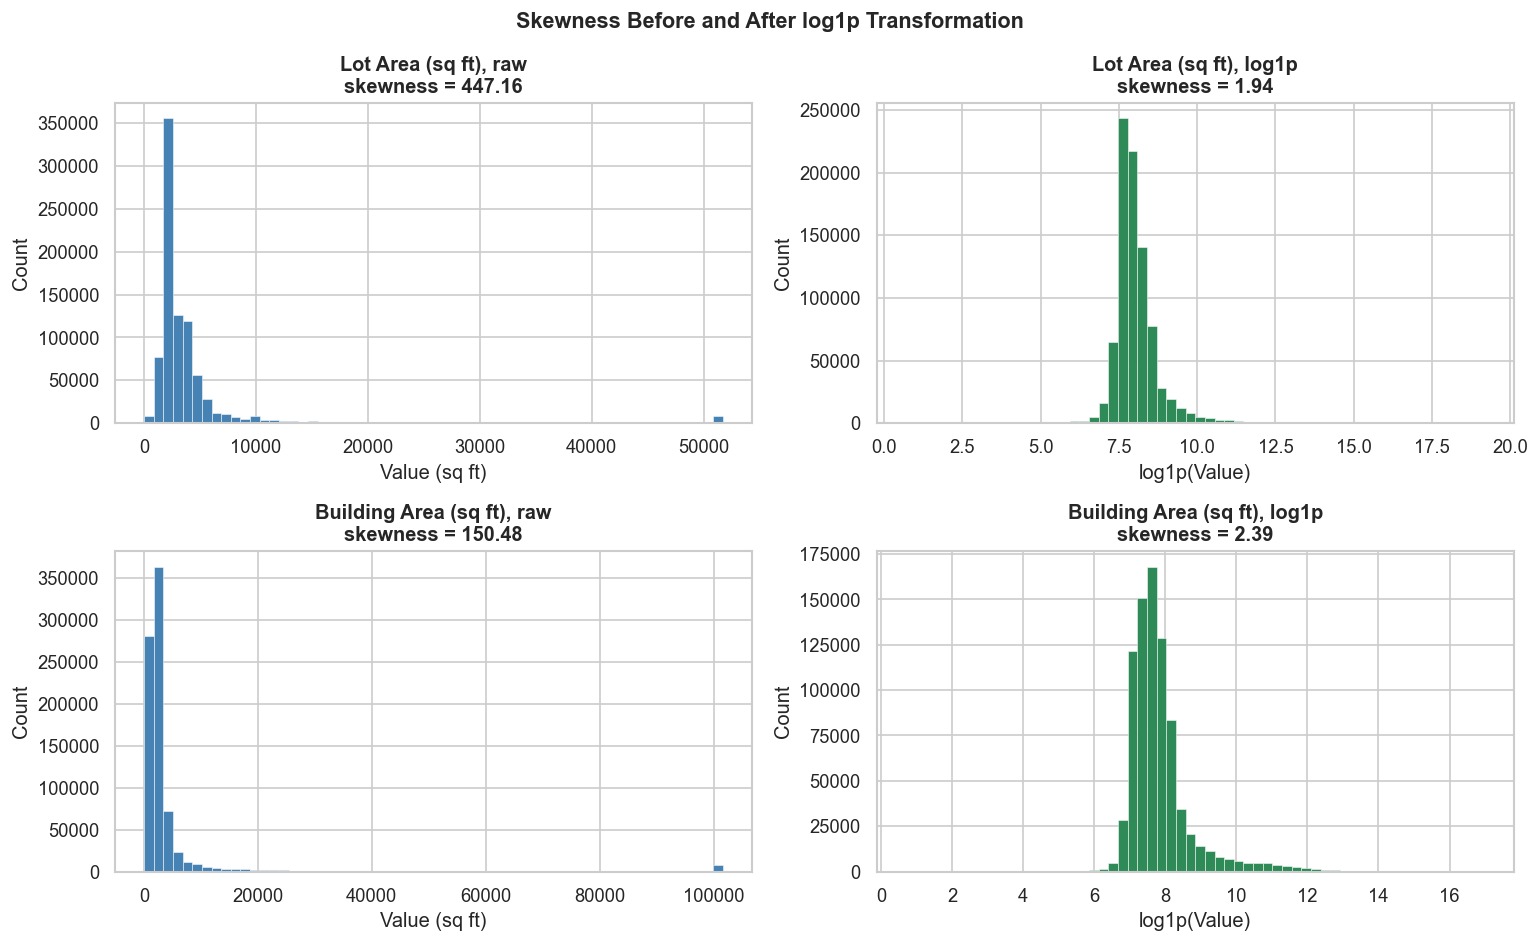

Saved: reports/figures/final_eda_skew_log.png


In [8]:
# Figure 1: raw vs log1p distributions for lotarea and bldgarea
_fig1, _axes1 = plt.subplots(2, 2, figsize=(13, 8))
_fig1.suptitle("Skewness Before and After log1p Transformation",
               fontsize=13, fontweight="bold")

for _row, (_col, _label) in enumerate([("lotarea", "Lot Area (sq ft)"),
                                        ("bldgarea", "Building Area (sq ft)")]):
    _series = df_eda[_col].dropna()
    _series = _series[_series > 0]
    _clip_val = _series.quantile(0.99)
    _skew_raw  = round(_series.skew(), 2)
    _skew_log  = round(np.log1p(_series).skew(), 2)

    # Raw
    _ax = _axes1[_row, 0]
    _ax.hist(_series.clip(upper=_clip_val), bins=60,
             color="steelblue", edgecolor="white", linewidth=0.3)
    _ax.set_title(f"{_label}, raw\nskewness = {_skew_raw}", fontweight="bold")
    _ax.set_xlabel("Value (sq ft)")
    _ax.set_ylabel("Count")

    # log1p
    _ax = _axes1[_row, 1]
    _ax.hist(np.log1p(_series), bins=60,
             color="seagreen", edgecolor="white", linewidth=0.3)
    _ax.set_title(f"{_label}, log1p\nskewness = {_skew_log}", fontweight="bold")
    _ax.set_xlabel("log1p(Value)")
    _ax.set_ylabel("Count")

plt.tight_layout()
_fig1_path = FIGURES_DIR / f"{FIG_PREFIX}eda_skew_log.png"
_fig1.savefig(_fig1_path, bbox_inches="tight")
plt.show()
print(f"Saved: {_fig1_path.relative_to(PROJECT_ROOT)}")

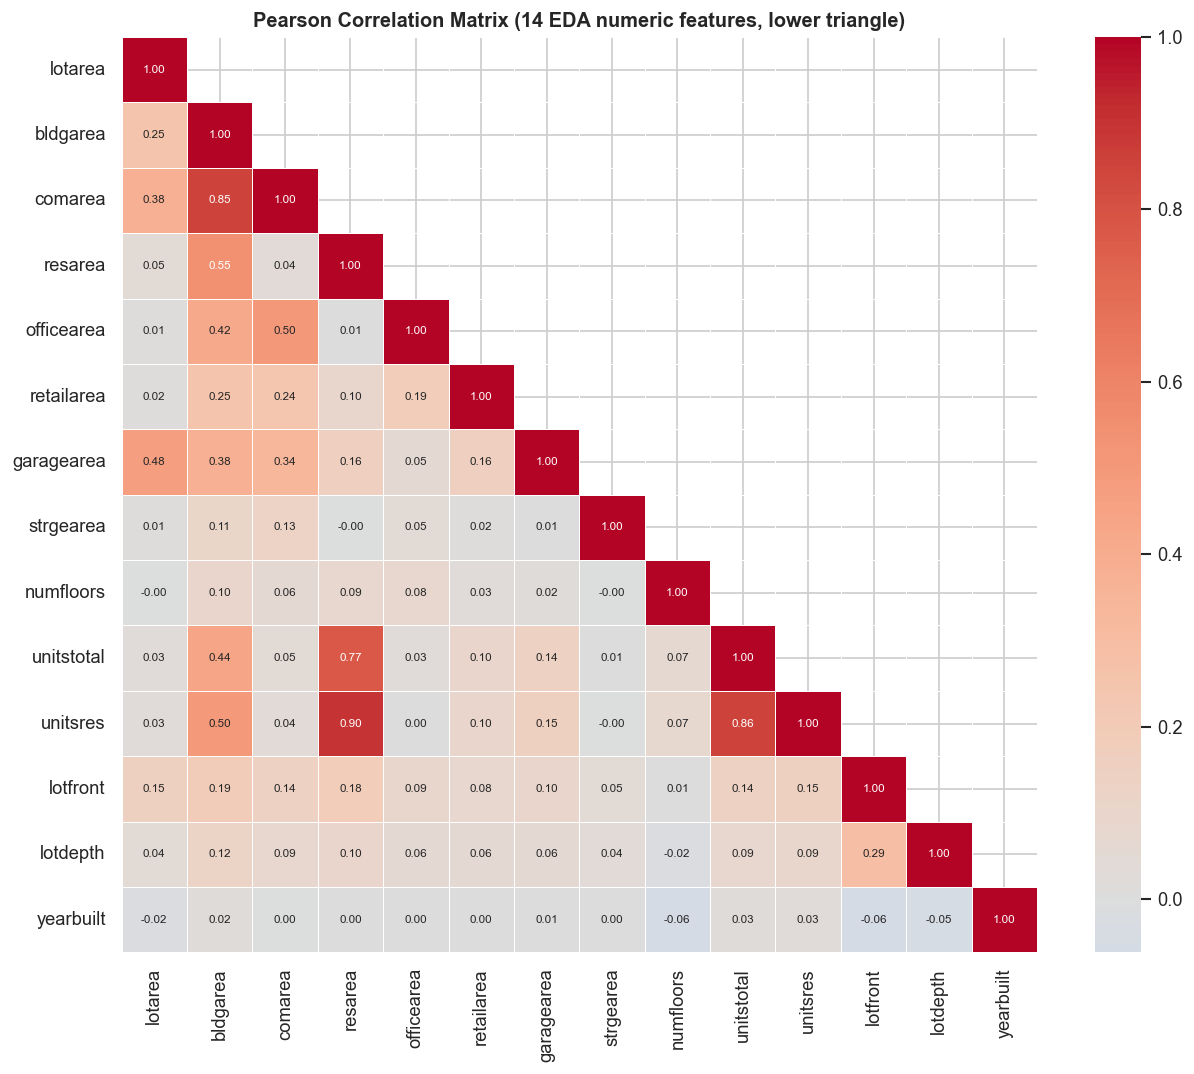

Saved: reports/figures/final_eda_correlation.png


In [9]:
# Figure 2: Pearson correlation heatmap (lower triangle)
_corr_plot = df_eda[EDA_NUMERIC].corr()
_mask_upper = np.triu(np.ones_like(_corr_plot, dtype=bool), k=1)

_fig2, _ax2 = plt.subplots(figsize=(11, 9))
sns.heatmap(
    _corr_plot,
    mask=_mask_upper,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0,
    linewidths=0.4,
    square=True,
    annot_kws={"size": 7},
    ax=_ax2,
)
_ax2.set_title("Pearson Correlation Matrix (14 EDA numeric features, lower triangle)",
               fontweight="bold")
plt.tight_layout()
_fig2_path = FIGURES_DIR / f"{FIG_PREFIX}eda_correlation.png"
_fig2.savefig(_fig2_path, bbox_inches="tight")
plt.show()
print(f"Saved: {_fig2_path.relative_to(PROJECT_ROOT)}")

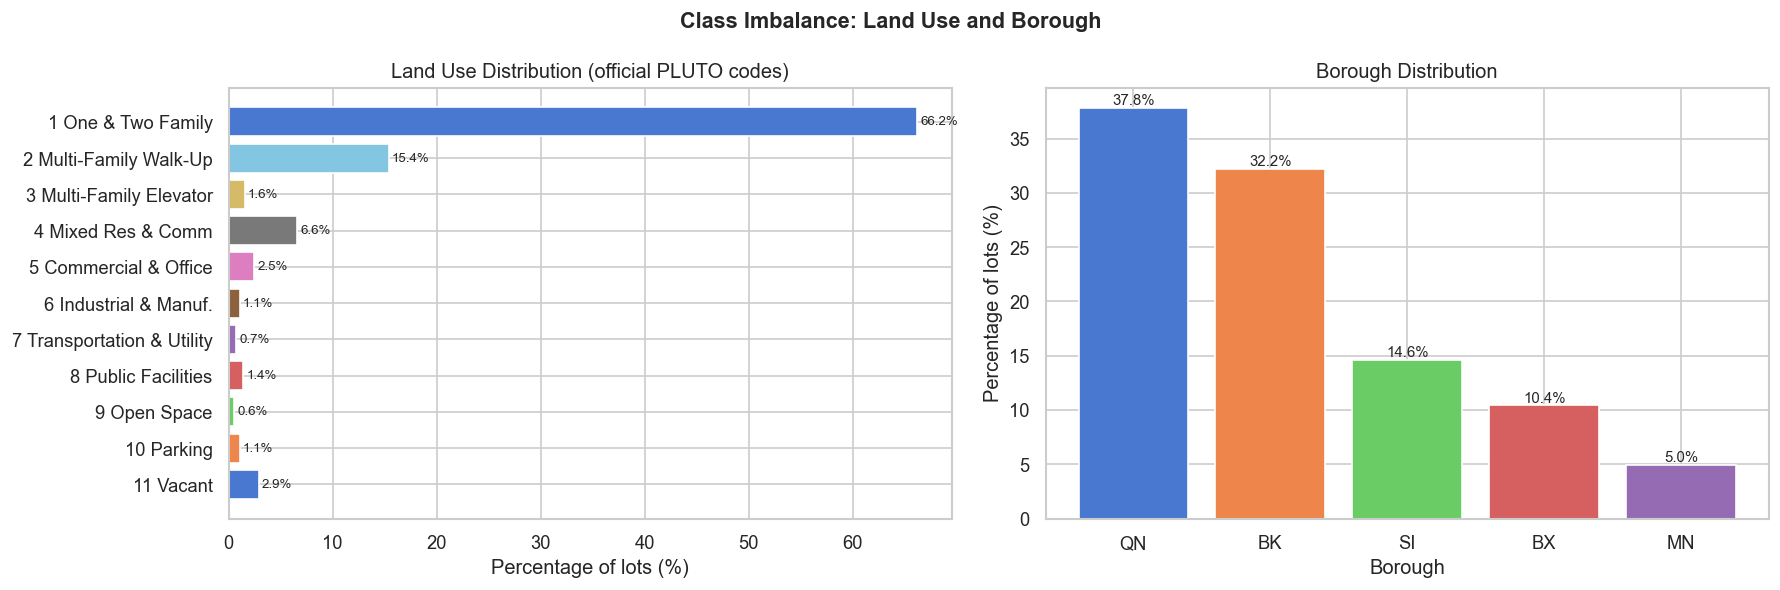

Saved: reports/figures/final_eda_imbalance.png
Brooklyn + Queens share of all lots: 70.0%


In [10]:
# Figure 3: landuse and borough distribution (class imbalance context)
_LANDUSE_LABELS = {
    1: "1 One & Two Family",
    2: "2 Multi-Family Walk-Up",
    3: "3 Multi-Family Elevator",
    4: "4 Mixed Res & Comm",
    5: "5 Commercial & Office",
    6: "6 Industrial & Manuf.",
    7: "7 Transportation & Utility",
    8: "8 Public Facilities",
    9: "9 Open Space",
    10: "10 Parking",
    11: "11 Vacant",
}

_lu_raw = pd.to_numeric(df_eda["landuse"], errors="coerce")
_lu_vc  = _lu_raw.value_counts().sort_index()
_lu_labels = [_LANDUSE_LABELS.get(int(k), str(k)) for k in _lu_vc.index]
_lu_pct = _lu_vc.values / _lu_vc.sum() * 100

_boro_vc = df_eda["borough"].value_counts()

_fig3, (_ax3a, _ax3b) = plt.subplots(1, 2, figsize=(15, 5))
_fig3.suptitle("Class Imbalance: Land Use and Borough", fontsize=13, fontweight="bold")

_ax3a.barh(_lu_labels[::-1], _lu_pct[::-1], color=sns.color_palette("muted", len(_lu_labels)))
_ax3a.set_xlabel("Percentage of lots (%)")
_ax3a.set_title("Land Use Distribution (official PLUTO codes)")
for _i, _v in enumerate(_lu_pct[::-1]):
    _ax3a.text(_v + 0.3, _i, f"{_v:.1f}%", va="center", fontsize=8)

_ax3b.bar(_boro_vc.index, _boro_vc.values / _boro_vc.sum() * 100,
          color=sns.color_palette("muted", len(_boro_vc)))
_ax3b.set_xlabel("Borough")
_ax3b.set_ylabel("Percentage of lots (%)")
_ax3b.set_title("Borough Distribution")
for _i, (_bname, _bval) in enumerate(zip(_boro_vc.index, _boro_vc.values)):
    _pct_b = _bval / _boro_vc.sum() * 100
    _ax3b.text(_i, _pct_b + 0.3, f"{_pct_b:.1f}%", ha="center", fontsize=9)

plt.tight_layout()
_fig3_path = FIGURES_DIR / f"{FIG_PREFIX}eda_imbalance.png"
_fig3.savefig(_fig3_path, bbox_inches="tight")
plt.show()
print(f"Saved: {_fig3_path.relative_to(PROJECT_ROOT)}")
_bkqn = df_eda["borough"].isin(["BK", "QN"]).mean() * 100
print(f"Brooklyn + Queens share of all lots: {_bkqn:.1f}%")

### Key takeaways from the EDA

**Skewness and log1p.** Area features (lot area, building area, unit and floor area
breakdowns) exhibit extreme right skewness: a small number of large commercial and
residential tower lots pull the distribution far to the right. Without transformation,
these extremes dominate the Euclidean distance used by K-Means. A `log1p` transformation
reduces skewness substantially and produces approximately symmetric distributions for
the large-valued area features. Features with a majority of zeros (most lots have no
office area, no retail area, etc.) retain a point mass at zero even after log1p; this
is a known limitation of the current feature set.

**Impossible values.** `yearbuilt == 0` is the PLUTO convention for an unknown construction
year. `bldgarea == 0` indicates a lot with no recorded building footprint. Both are set to
NaN before any transformation.

**Correlated features and PCA motivation.** Several pairs of area and unit-count features
show Pearson correlations above 0.80 (residential area and residential units, for example).
These redundant dimensions do not add information to the clustering but increase the
dimensionality of the distance computation. PCA in Section 5 compresses them into a smaller
set of orthogonal components while retaining more than 90% of total variance.

**Land use and borough imbalance.** One and Two Family lots (code 1) account for the large
majority of the dataset. Brooklyn and Queens together represent roughly 70% of all lots.
These imbalances are context for the cluster sizes found later. Crucially, `landuse` is
withheld from clustering: including it as a one-hot input would cause K-Means to recover
the input categories rather than discover morphological structure (see Section 4).

## Section 4: Preprocessing

This section describes the preprocessing pipeline that produced `X_scaled.csv`. The pipeline
runs in `notebooks/02_clustering/processing_and_clustering.ipynb` and is reproduced faithfully
here. All steps are described in the order they were applied.

### Step 1: Numeric parsing

The raw PLUTO export uses a narrow no-break space (U+202F) as a thousands separator
(a French locale export artifact). All numeric columns are converted to string, stripped
of whitespace and non-numeric characters, then coerced to float with `pd.to_numeric(...,
errors="coerce")`.

### Step 2: Impossible values to NaN

Three rules identify structurally invalid records:
- `yearbuilt == 0`: the PLUTO data dictionary uses 0 to encode an unknown construction year.
- `bldgarea == 0`: a lot with no recorded building area cannot contribute meaningful area
  features.
- `numfloors > 104`: One World Trade Center has 104 floors; larger values are data-entry
  artifacts. Additionally, `numfloors > 4` is set to NaN for one-and-two-family lots
  (landuse code 1), which cannot physically exceed four floors; these are copy errors from
  adjacent high-rise records.

### Step 3: IQR winsorization

Seven features with heavy-tailed outliers are winsorized at the 1.5 x IQR fence:
`lotfront`, `lotdepth`, `lotarea`, `bldgarea`, `unitstotal`, `resarea`, and `yearbuilt`.
Winsorization is preferred over dropping because the outlier values are plausible (very large
lots exist in industrial areas) but would dominate the distance computation without bounding.

### Step 4: Engineered features

Three derived features are computed from the winsorized values:
- `building_age`: `2026 - yearbuilt`. Rows where yearbuilt is NaN (originally zero) yield
  a NaN age and are dropped at Step 5.
- `building_density`: `bldgarea / lotarea`. Undefined when lot area is zero or missing.
- `residential_ratio`: `unitsres / unitstotal`. Defined as 0.0 when `unitstotal == 0`
  (the lot has no units, so 0% residential is the correct value, not missing). Clipped to
  `[0, 1]` because `unitstotal` was winsorized but `unitsres` was not, which can produce
  a raw ratio slightly above 1.

### Step 5: Drop rows with any missing clustering feature

After Steps 2 to 4, rows that still have at least one NaN across the 16 clustering features
are dropped. This is the primary source of the row reduction from the raw count to 682,515.

### Step 6: log1p transformation

Eleven features with right-skewed distributions receive a `log1p` transformation before
scaling: `lotarea`, `bldgarea`, `unitstotal`, `unitsres`, `resarea`, `comarea`,
`officearea`, `retailarea`, `garagearea`, `strgearea`, and `building_density`. The remaining
five (`numfloors`, `lotfront`, `lotdepth`, `building_age`, `residential_ratio`) are
approximately symmetric after winsorization and do not require log transformation.

### Step 7: StandardScaler

All 16 features are standardized to mean 0 and standard deviation 1 using `StandardScaler`
fitted on the full cleaned dataset. This ensures that no single feature dominates the
Euclidean distance computation in K-Means or PCA regardless of its original unit.

### Reconciliation 1: landuse exclusion

The Phase 1 EDA synthesis recommended one-hot encoding `landuse` as a clustering input.
This recommendation was deliberately superseded in the final pipeline for two reasons.
First, one-hot indicators produce binary columns with no within-category variation; after
`StandardScaler` they carry disproportionate geometric weight relative to continuous features.
Second, K-Means with `landuse` as input recovers the input categories rather than discovering
new structure: the "clusters" mirror landuse-code frequencies and provide no information beyond
the original labels. The approach adopted here is to cluster on physical and functional
measurements only, then cross-tabulate discovered clusters against `landuse` in Section 7 as
a blind post-hoc validation. Any correlation between clusters and land use categories is a
finding, not a built-in assumption.

### Reconciliation 2: correlated features retained

Strongly correlated features (`resarea` and `unitsres`, `unitstotal` and `unitsres`, etc.)
were NOT removed manually. Manual feature selection based on pairwise correlations is
arbitrary and discards potentially useful variance. Instead, redundancy is addressed
structurally in Section 5 by PCA, which compresses correlated dimensions into a smaller set
of orthogonal components while retaining more than 90% of total variance.

In [11]:
# Confirm the 16-feature list
print("Clustering features (16):")
for _i, _f in enumerate(feature_names, 1):
    print(f"  {_i:2d}. {_f}")
print()

# Verify landuse and borough are absent from X_scaled (present only in companion)
_excluded = ["landuse", "borough"]
for _col in _excluded:
    _in_xscaled = _col in X_scaled.columns
    _in_companion = _col in companion.columns
    print(f"  '{_col}' in X_scaled   : {_in_xscaled}  (expected: False)")
    print(f"  '{_col}' in companion  : {_in_companion}  (expected: True)")
print()

# Row reduction summary
_raw_path_s4 = PROJECT_ROOT / "data" / "raw" / "pluto_working_copy.csv"
_raw_n = len(pd.read_csv(_raw_path_s4, usecols=[0], low_memory=False))
_clean_n = len(X_scaled)
print(f"Raw rows    : {_raw_n:,}")
print(f"Clean rows  : {_clean_n:,}")
print(f"Rows removed: {_raw_n - _clean_n:,} ({(_raw_n - _clean_n) / _raw_n * 100:.1f}%)")

Clustering features (16):
   1. lotarea
   2. bldgarea
   3. numfloors
   4. lotfront
   5. lotdepth
   6. unitstotal
   7. unitsres
   8. resarea
   9. comarea
  10. officearea
  11. retailarea
  12. garagearea
  13. strgearea
  14. building_age
  15. building_density
  16. residential_ratio

  'landuse' in X_scaled   : False  (expected: False)
  'landuse' in companion  : True  (expected: True)
  'borough' in X_scaled   : False  (expected: False)
  'borough' in companion  : True  (expected: True)



Raw rows    : 858,644
Clean rows  : 682,515
Rows removed: 176,129 (20.5%)


## Section 5: Representation through Dimensionality Reduction

### Why reduce dimension here

The exploratory analysis showed that several feature groups share most of their variance:
residential area and residential unit count move together, total and residential unit counts
overlap, and total building area tracks commercial area. In a Euclidean distance space,
correlated dimensions are effectively counted more than once, which distorts inter-point
distances and the density estimates that clustering relies on. Principal Component Analysis
addresses this by rotating the data onto orthogonal axes ordered by variance, removing the
redundancy without discarding the information it carries.

This also reflects a deliberate methodological change. An earlier version of this project
clustered directly in the full sixteen dimensional standardized space. Following the standard
standardize, reduce, then cluster pipeline, and to remove the redundancy noted above, we now
apply PCA before clustering. The sections below verify that this change does not degrade the
K-Means result, and Section 6 shows that it sharpens the density based view. PCA is applied to
the standardized matrix, which already excludes borough and land use, so no administrative
label enters the representation.

Components needed for >= 90% cumulative variance: 10
Cumulative variance at 10 components        : 92.1940%

  PC  Indiv. var (%)  Cumul. var (%)
PC 1         24.4905         24.4905
PC 2         19.2046         43.6951
PC 3         10.0369         53.7320
PC 4          6.8533         60.5853
PC 5          5.8502         66.4355
PC 6          5.6085         72.0439
PC 7          5.4593         77.5033
PC 8          5.1853         82.6886
PC 9          4.8939         87.5825
PC10          4.6116         92.1940 <-- selected
PC11          3.4836         95.6777
PC12          1.9447         97.6224
PC13          1.3812         99.0036
PC14          0.6347         99.6383
PC15          0.2471         99.8854
PC16          0.1146        100.0000


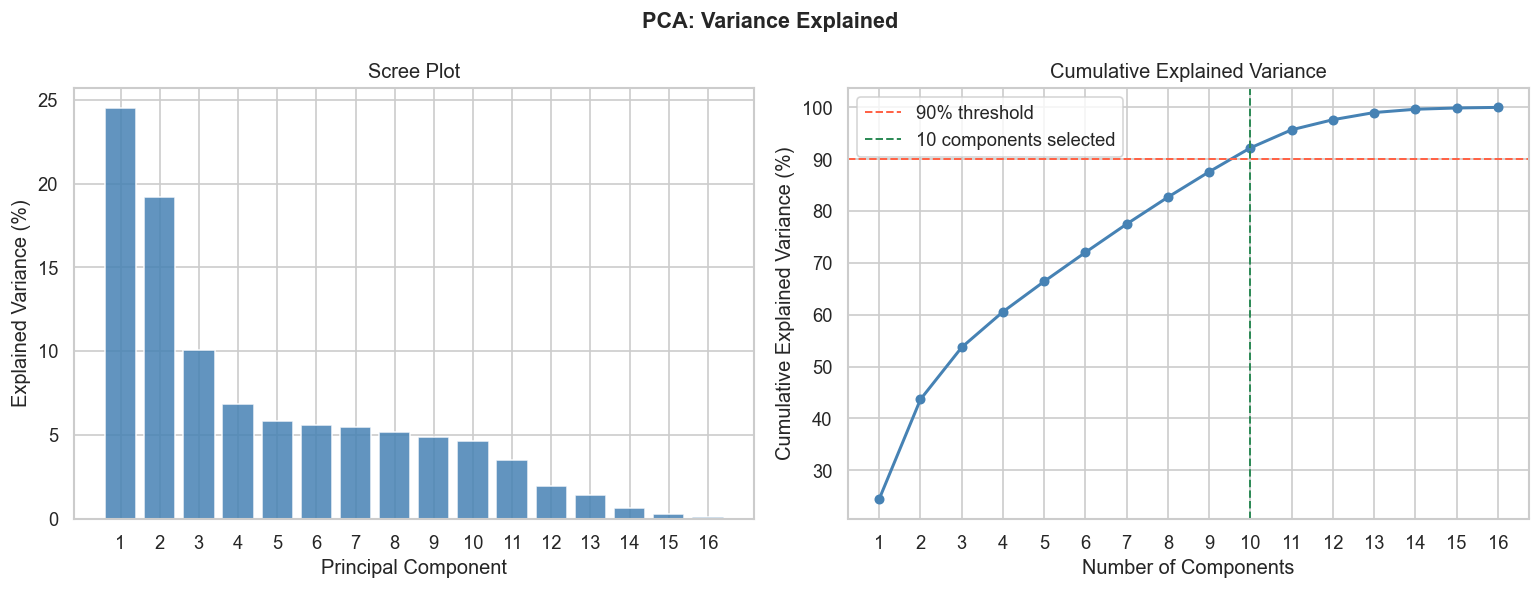

Saved: reports/figures/final_pca_variance.png


In [12]:
# Full-rank PCA to determine how many components reach 90% cumulative variance
_X_arr = X_scaled.to_numpy(dtype=np.float64)

pca_full = PCA(random_state=RANDOM_STATE)
pca_full.fit(_X_arr)
_ev      = pca_full.explained_variance_ratio_
cumvar   = np.cumsum(_ev)
n_comp   = int(np.argmax(cumvar >= 0.90)) + 1

print(f"Components needed for >= 90% cumulative variance: {n_comp}")
print(f"Cumulative variance at {n_comp} components        : {cumvar[n_comp - 1] * 100:.4f}%")
print()
print(f"{'PC':>4}  {'Indiv. var (%)':>14}  {'Cumul. var (%)':>14}")
for i in range(len(_ev)):
    marker = " <-- selected" if i + 1 == n_comp else ""
    print(f"PC{i+1:>2}  {_ev[i]*100:>14.4f}  {cumvar[i]*100:>14.4f}{marker}")

# Figure: scree plot + cumulative variance
_fig_var, (_ax_scree, _ax_cumvar) = plt.subplots(1, 2, figsize=(13, 5))
_fig_var.suptitle("PCA: Variance Explained", fontsize=13, fontweight="bold")

_ax_scree.bar(range(1, len(_ev) + 1), _ev * 100, color="steelblue", alpha=0.85)
_ax_scree.set_xlabel("Principal Component")
_ax_scree.set_ylabel("Explained Variance (%)")
_ax_scree.set_title("Scree Plot")
_ax_scree.set_xticks(range(1, len(_ev) + 1))

_ax_cumvar.plot(range(1, len(cumvar) + 1), cumvar * 100,
                marker="o", markersize=5, linewidth=1.8, color="steelblue")
_ax_cumvar.axhline(90, color="tomato", linestyle="--", linewidth=1.2,
                   label="90% threshold")
_ax_cumvar.axvline(n_comp, color="seagreen", linestyle="--", linewidth=1.2,
                   label=f"{n_comp} components selected")
_ax_cumvar.set_xlabel("Number of Components")
_ax_cumvar.set_ylabel("Cumulative Explained Variance (%)")
_ax_cumvar.set_title("Cumulative Explained Variance")
_ax_cumvar.legend()
_ax_cumvar.set_xticks(range(1, len(cumvar) + 1))

plt.tight_layout()
_fig_var_path = FIGURES_DIR / f"{FIG_PREFIX}pca_variance.png"
_fig_var.savefig(_fig_var_path, bbox_inches="tight")
plt.show()
print(f"Saved: {_fig_var_path.relative_to(PROJECT_ROOT)}")

X_pca shape        : (682515, 10)
X_pca_sample shape : (10000, 10)

PC1 loadings (sorted by magnitude):
  comarea                 +0.4638
  residential_ratio       -0.4089
  resarea                 -0.3294
  retailarea              +0.3287
  bldgarea                +0.3279
  officearea              +0.2911
  garagearea              +0.1720
  lotarea                 +0.1678
  strgearea               +0.1670
  building_density        +0.1669
  unitstotal              +0.1652
  numfloors               +0.1609
  lotdepth                +0.1542
  lotfront                +0.1303
  unitsres                +0.0283
  building_age            +0.0255

PC2 loadings (sorted by magnitude):
  unitsres                +0.4762
  unitstotal              +0.4637
  resarea                 +0.3737
  building_density        +0.3655
  bldgarea                +0.3205
  residential_ratio       +0.2749
  numfloors               +0.2231
  building_age            +0.1229
  strgearea               -0.0895
  lotarea

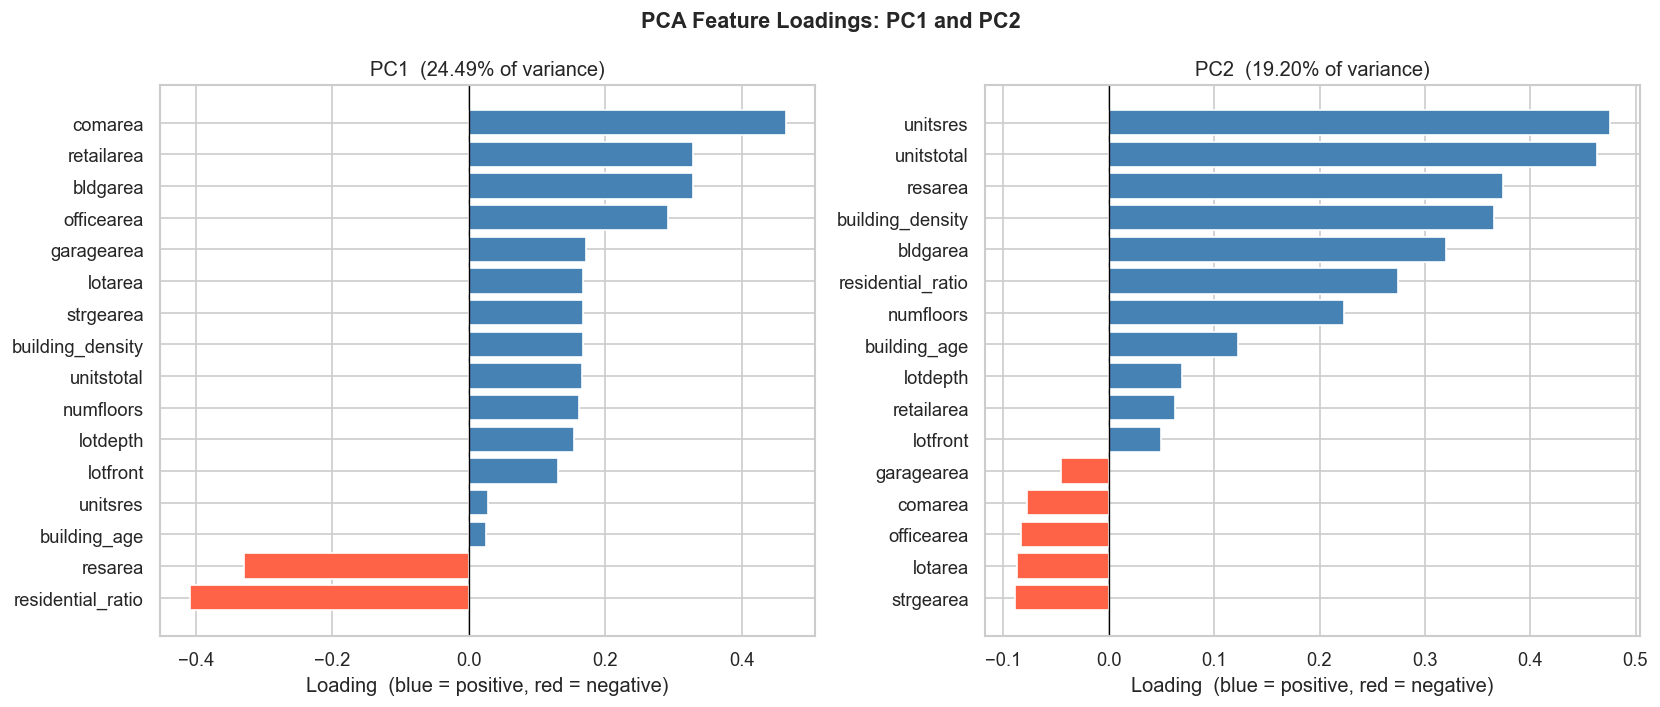

Saved: reports/figures/final_pca_loadings.png


In [13]:
# Fit the final PCA with the selected number of components
pca = PCA(n_components=n_comp, random_state=RANDOM_STATE)
_X_pca_arr = pca.fit_transform(_X_arr)

# Full transformed matrix: same index as X_scaled, columns PC1..PCk
X_pca = pd.DataFrame(
    _X_pca_arr,
    index=X_scaled.index,
    columns=[f"PC{i + 1}" for i in range(n_comp)],
)

# Working sample in PCA space (same rows as X_sample)
X_pca_sample = X_pca.iloc[sample_idx].copy()

print(f"X_pca shape        : {X_pca.shape}")
print(f"X_pca_sample shape : {X_pca_sample.shape}")
print()

# Print loadings for PC1 and PC2 sorted by absolute magnitude
for _pc_idx, _pc_name in [(0, "PC1"), (1, "PC2")]:
    _load = pd.Series(pca.components_[_pc_idx], index=feature_names, name=_pc_name)
    _load_sorted = _load.reindex(_load.abs().sort_values(ascending=False).index)
    print(f"{_pc_name} loadings (sorted by magnitude):")
    for _feat, _val in _load_sorted.items():
        _sign = "+" if _val >= 0 else ""
        print(f"  {_feat:<22s}  {_sign}{_val:.4f}")
    print()

# Figure: loadings bar chart for PC1 and PC2
_fig_load, _axes_load = plt.subplots(1, 2, figsize=(14, 6))
_fig_load.suptitle("PCA Feature Loadings: PC1 and PC2", fontsize=13, fontweight="bold")

for _ax, _pc_idx, _pc_name in [
    (_axes_load[0], 0, "PC1"),
    (_axes_load[1], 1, "PC2"),
]:
    _load_vals = pca.components_[_pc_idx]
    _order = np.argsort(_load_vals)          # ascending: negative at top, positive at bottom
    _sorted_vals  = _load_vals[_order]
    _sorted_feats = [feature_names[i] for i in _order]
    _colors = ["steelblue" if v >= 0 else "tomato" for v in _sorted_vals]

    _ax.barh(_sorted_feats, _sorted_vals, color=_colors)
    _ax.axvline(0, color="black", linewidth=0.8)
    _ax.set_xlabel("Loading")
    _var_pct = pca.explained_variance_ratio_[_pc_idx] * 100
    _ax.set_title(f"{_pc_name}  ({_var_pct:.2f}% of variance)")
    _ax.set_xlabel("Loading  (blue = positive, red = negative)")

plt.tight_layout()
_fig_load_path = FIGURES_DIR / f"{FIG_PREFIX}pca_loadings.png"
_fig_load.savefig(_fig_load_path, bbox_inches="tight")
plt.show()
print(f"Saved: {_fig_load_path.relative_to(PROJECT_ROOT)}")

### What the first two components represent

The first principal component contrasts commercial use against residential use. The commercial
area features and overall building size load on one side, while residential ratio and
residential floor area load on the opposite side. A lot at the commercial end is large and
commercially oriented, a lot at the residential end is dominated by housing. This axis is best
read as a use mix axis with a size correlate.

The second principal component captures residential intensity. Residential and total unit
counts, residential floor area, building density, and number of floors load together in the
same direction. The axis measures how intensively a parcel is developed for housing, from low
density homes to dense multi unit buildings.

Together the two axes separate what a building is used for from how intensively it is developed
for residential use. These axes describe the geometry. Cluster interpretation in Section 7 is
done on the original features, not on the components, because each component is a linear
combination of all sixteen features and does not map to a single building attribute.

In [14]:
# Robustness: K-Means k=2 in full 16D space vs. PCA space, same 10,000-row sample
_X_16d = X_sample.to_numpy(dtype=np.float64)
_X_pca = X_pca_sample.to_numpy(dtype=np.float64)

_km_16d = KMeans(n_clusters=2, init="k-means++", n_init=10,
                 max_iter=300, random_state=RANDOM_STATE)
_lbl_16d = _km_16d.fit_predict(_X_16d)
_sil_16d = silhouette_score(_X_16d, _lbl_16d,
                             sample_size=10_000, random_state=RANDOM_STATE)

_km_pca2 = KMeans(n_clusters=2, init="k-means++", n_init=10,
                  max_iter=300, random_state=RANDOM_STATE)
_lbl_pca2 = _km_pca2.fit_predict(_X_pca)
_sil_pca2 = silhouette_score(_X_pca, _lbl_pca2,
                              sample_size=10_000, random_state=RANDOM_STATE)

_ari_rob = adjusted_rand_score(_lbl_16d, _lbl_pca2)
_ami_rob = adjusted_mutual_info_score(_lbl_16d, _lbl_pca2)

print("K-Means k=2 robustness: full 16D space vs. PCA space (same 10,000-row sample)")
print(f"  {'':30s}  {'16D':>8}  {'PCA':>8}")
print(f"  {'Silhouette':30s}  {_sil_16d:>8.4f}  {_sil_pca2:>8.4f}")
print()
print(f"  ARI between 16D and PCA partitions: {_ari_rob:.4f}  (1.0 = identical)")
print(f"  AMI between 16D and PCA partitions: {_ami_rob:.4f}  (1.0 = identical)")
print()

# Cluster size comparison
for _name, _lbls in [("16D", _lbl_16d), ("PCA", _lbl_pca2)]:
    _unique, _counts = np.unique(_lbls, return_counts=True)
    _sizes = {int(u): int(c) for u, c in zip(_unique, _counts)}
    print(f"  Cluster sizes ({_name}): {_sizes}")

K-Means k=2 robustness: full 16D space vs. PCA space (same 10,000-row sample)
                                       16D       PCA
  Silhouette                        0.4676    0.4729

  ARI between 16D and PCA partitions: 0.9969  (1.0 = identical)
  AMI between 16D and PCA partitions: 0.9886  (1.0 = identical)

  Cluster sizes (16D): {0: 8481, 1: 1519}
  Cluster sizes (PCA): {0: 8481, 1: 1519}


### Effect on clustering, interpretability, and the role of PCA

**Effect on clustering performance.** Comparing K-Means with k=2 in the full space and in the
PCA space on the same rows, the silhouette scores are nearly identical and the two partitions
agree almost perfectly (the Adjusted Rand Index is printed above). PCA does not improve cluster
separation here, which is expected, since it maximizes variance, not class separation. What it
provides is robustness evidence: the two group structure is the same whether or not the data is
reduced, so it is a property of the data rather than an artifact of the representation.

**Effect on interpretability.** The leading components are interpretable as a use mix axis and a
residential intensity axis, which helps describe the geometry. The components themselves are
not used to label clusters, since each mixes all original features.

**Advantages and limitations.** PCA decorrelates the features and yields a cleaner distance and
density landscape, which benefits the density based method in Section 6. Its main limitation
here is weak compression: reaching the ninety percent variance threshold requires the majority
of the components (the exact count is printed above), so the dataset does not collapse to a
compact low dimensional form. The reduction is useful for decorrelation and as a robustness
check rather than for aggressive compression.

**NMF is not applicable to this representation.** Non negative matrix factorization requires a
non negative input matrix, and the standardized matrix contains negative values by construction,
so NMF is outside the scope of this analysis.

## Section 6: Clustering Analysis

### 6.1 K-Means

All clustering in this section is performed in the PCA space established in Section 5, the
representation recommended by the standard pipeline and confirmed there to preserve the
structure of the data. K-Means is the primary algorithm: it partitions every lot into a fixed
number of groups by minimizing within cluster variance, which produces a stable and directly
interpretable segmentation.

K-Means selection metrics (PCA space, 10,000-row sample):
    inertia  silhouette  calinski_harabasz  davies_bouldin
k                                                         
2  113993.1      0.4729             2674.4          1.6408
3   93648.2      0.3079             2713.5          1.4990
4   85285.4      0.2501             2312.9          1.5316
5   78234.6      0.2545             2116.0          1.4400
6   71325.1      0.2190             2050.2          1.4105
7   64935.4      0.2452             2040.4          1.2643
8   61358.9      0.2207             1933.8          1.3099
Best k by silhouette: 2


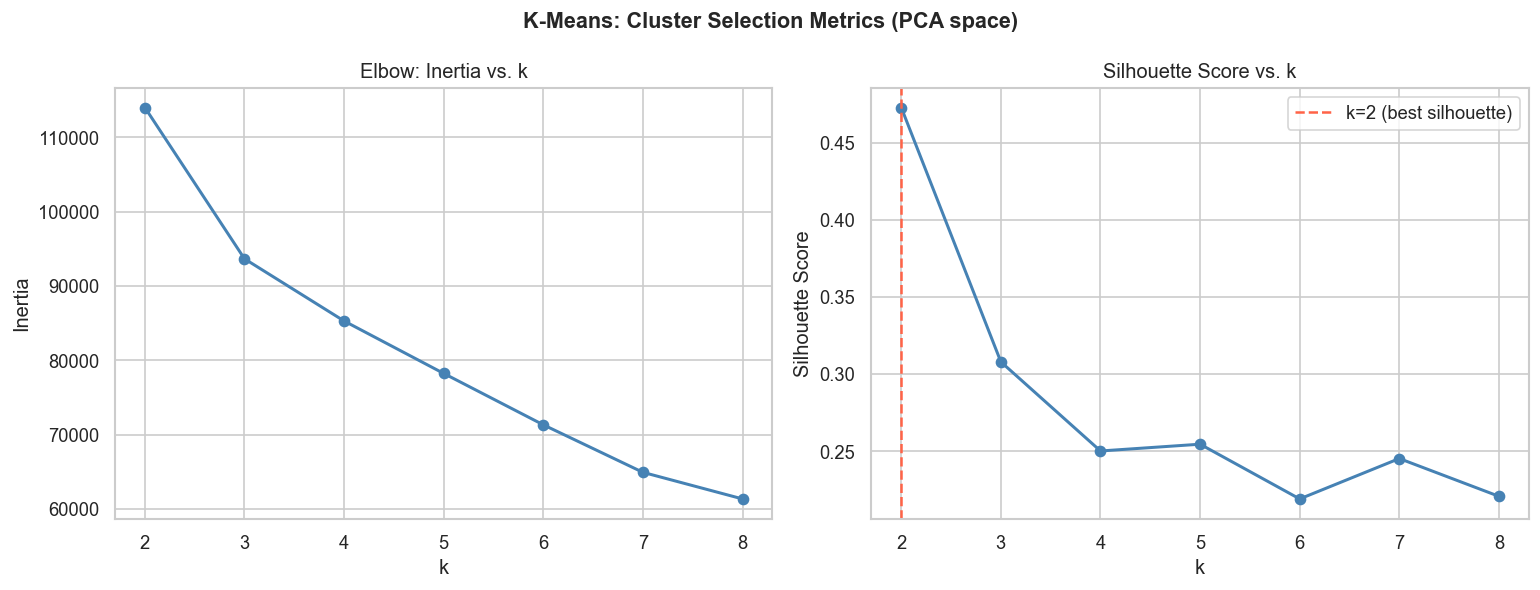

Saved: reports/figures/final_kmeans_selection.png


In [15]:
# K selection: run K-Means for k = 2..8 on the 10,000-row PCA sample
_X_samp = X_pca_sample.to_numpy(dtype=np.float64)

_k_rows = []
for _k in range(2, 9):
    _km = KMeans(n_clusters=_k, init="k-means++", n_init=10,
                 max_iter=300, random_state=RANDOM_STATE)
    _lbl = _km.fit_predict(_X_samp)
    _sil = silhouette_score(_X_samp, _lbl, sample_size=10_000, random_state=RANDOM_STATE)
    _ch  = calinski_harabasz_score(_X_samp, _lbl)
    _db  = davies_bouldin_score(_X_samp, _lbl)
    _k_rows.append({
        "k":                  _k,
        "inertia":            round(_km.inertia_, 1),
        "silhouette":         round(_sil, 4),
        "calinski_harabasz":  round(_ch, 1),
        "davies_bouldin":     round(_db, 4),
    })

results_df = pd.DataFrame(_k_rows).set_index("k")
print("K-Means selection metrics (PCA space, 10,000-row sample):")
print(results_df.to_string())

best_k = int(results_df["silhouette"].idxmax())
print(f"Best k by silhouette: {best_k}")

# Figure: elbow + silhouette
_fig_sel, (_ax_elbow, _ax_sil) = plt.subplots(1, 2, figsize=(13, 5))
_fig_sel.suptitle("K-Means: Cluster Selection Metrics (PCA space)",
                  fontsize=13, fontweight="bold")

_ax_elbow.plot(results_df.index, results_df["inertia"],
               marker="o", linewidth=1.8, color="steelblue")
_ax_elbow.set_xlabel("k")
_ax_elbow.set_ylabel("Inertia")
_ax_elbow.set_title("Elbow: Inertia vs. k")
_ax_elbow.set_xticks(list(results_df.index))

_ax_sil.plot(results_df.index, results_df["silhouette"],
             marker="o", linewidth=1.8, color="steelblue")
_ax_sil.axvline(best_k, color="tomato", linestyle="--",
                label=f"k={best_k} (best silhouette)")
_ax_sil.set_xlabel("k")
_ax_sil.set_ylabel("Silhouette Score")
_ax_sil.set_title("Silhouette Score vs. k")
_ax_sil.set_xticks(list(results_df.index))
_ax_sil.legend()

plt.tight_layout()
_fig_sel_path = FIGURES_DIR / f"{FIG_PREFIX}kmeans_selection.png"
_fig_sel.savefig(_fig_sel_path, bbox_inches="tight")
plt.show()
print(f"Saved: {_fig_sel_path.relative_to(PROJECT_ROOT)}")

### Choosing the number of clusters

The decision rule, fixed in advance, selects the k that maximizes the silhouette score in the
PCA space where K-Means runs. By this rule the optimal partition is k=2, a clean and well
separated split with the highest silhouette of any candidate. This two group partition is the
primary clustering result of the project and the most statistically defensible.

The research question, however, asks how building typologies are structured across the boroughs
and what urban configurations emerge. A binary residential versus non residential split is too
coarse to describe the typological diversity of the city. We therefore also examine a finer
partition at k=5, adopted as an interpretive segmentation rather than as the silhouette optimum.
Its silhouette is lower than that of k=2, which we report openly: the value of k=5 lies in
interpretability, not in maximizing a separation metric. The choice of five is supported by the
structure of the data, the primary split persists while the residential mass resolves into two
typologies and the commercial and mixed use mass into three, and the hierarchical view in
Section 6.3 makes this nesting visible. Both partitions are reported: k=2 is the robust primary
result, k=5 is the interpretive lens used to answer the research question.

In [16]:
# Fit K-Means k=2 and k=5 on the full PCA matrix (682,515 rows)
_X_full = X_pca.to_numpy(dtype=np.float64)
_X_samp = X_pca_sample.to_numpy(dtype=np.float64)

km_k2 = KMeans(n_clusters=2, init="k-means++", n_init=10,
               max_iter=300, random_state=RANDOM_STATE)
labels_full_k2 = km_k2.fit_predict(_X_full)

km_k5 = KMeans(n_clusters=5, init="k-means++", n_init=10,
               max_iter=300, random_state=RANDOM_STATE)
labels_full_k5 = km_k5.fit_predict(_X_full)

# Project onto the working sample using predict (no refitting)
labels_sample_k2 = km_k2.predict(_X_samp)
labels_sample_k5 = km_k5.predict(_X_samp)

# Cluster counts
_cnt_k2 = dict(zip(*np.unique(labels_full_k2, return_counts=True)))
_cnt_k2 = {int(k): int(v) for k, v in _cnt_k2.items()}
_cnt_k5 = dict(zip(*np.unique(labels_full_k5, return_counts=True)))
_cnt_k5 = {int(k): int(v) for k, v in _cnt_k5.items()}

# Verify k=5 cluster IDs against recon reference
_expected_k5 = {0: 334_240, 1: 70_941, 2: 7_028, 3: 44_883, 4: 225_423}
print("K=5 cluster ID verification against reference:")
_all_ok = True
for _cl, _exp in _expected_k5.items():
    _act = _cnt_k5.get(_cl, -1)
    _ok  = _act == _exp
    if not _ok:
        _all_ok = False
    print(f"  cluster {_cl}: expected {_exp:>7,}  actual {_act:>7,}  {'OK' if _ok else '*** MISMATCH ***'}")
print(f"All cluster IDs match reference: {_all_ok}")
print()

# Silhouettes computed on the sample
_sil_k2 = silhouette_score(_X_samp, labels_sample_k2, random_state=RANDOM_STATE)
_sil_k5 = silhouette_score(_X_samp, labels_sample_k5, random_state=RANDOM_STATE)

# Print sizes + silhouettes
print(f"K=2 (full data, {len(labels_full_k2):,} lots):")
for _cl in sorted(_cnt_k2):
    _n = _cnt_k2[_cl]
    print(f"  cluster {_cl}: {_n:>7,}  ({_n / len(labels_full_k2) * 100:.2f}%)")
print(f"  Silhouette (10,000-row sample): {_sil_k2:.4f}")
print()

print(f"K=5 (full data, {len(labels_full_k5):,} lots):")
for _cl in sorted(_cnt_k5):
    _n = _cnt_k5[_cl]
    print(f"  cluster {_cl}: {_n:>7,}  ({_n / len(labels_full_k5) * 100:.2f}%)")
print(f"  Silhouette (10,000-row sample): {_sil_k5:.4f}")
print()

# Attach labels to companion DataFrames for Sections 7 and 8
companion["cluster_k2"] = labels_full_k2
companion["cluster_k5"] = labels_full_k5
companion_sample = companion_sample.copy()
companion_sample["cluster_k2"] = labels_sample_k2
companion_sample["cluster_k5"] = labels_sample_k5

print("Labels attached to companion and companion_sample.")
print(f"New companion columns: {[c for c in companion.columns if 'cluster' in c]}")

K=5 cluster ID verification against reference:
  cluster 0: expected 334,240  actual 334,240  OK
  cluster 1: expected  70,941  actual  70,941  OK
  cluster 2: expected   7,028  actual   7,028  OK
  cluster 3: expected  44,883  actual  44,883  OK
  cluster 4: expected 225,423  actual 225,423  OK
All cluster IDs match reference: True



K=2 (full data, 682,515 lots):
  cluster 0: 104,504  (15.31%)
  cluster 1: 578,011  (84.69%)
  Silhouette (10,000-row sample): 0.4734

K=5 (full data, 682,515 lots):
  cluster 0: 334,240  (48.97%)
  cluster 1:  70,941  (10.39%)
  cluster 2:   7,028  (1.03%)
  cluster 3:  44,883  (6.58%)
  cluster 4: 225,423  (33.03%)
  Silhouette (10,000-row sample): 0.2193

Labels attached to companion and companion_sample.
New companion columns: ['cluster_k2', 'cluster_k5']


### The two reported partitions

At k=2 the data splits into a large residential group and a smaller non residential group, the
robust primary result. At k=5 the residential mass resolves into two typologies and the
commercial and mixed use mass into three, giving five interpretable groups. The cluster sizes
are printed above. Each of the five typologies is described in detail in Section 7; here we only
establish the partitions and their sizes. The final K-Means models are fit on the full set of
lots, so the segmentation applies to every building and not only to the working sample, while
the silhouette scores are computed on the sample for tractability.

### 6.2 DBSCAN

### From the full space to the PCA space

K-Means always returns a fixed number of groups. A density based method such as DBSCAN provides
an independent check: it finds dense regions of arbitrary shape and labels sparse points as
noise, so it can either confirm the K-Means split or reveal finer structure. An earlier version
of this project ran DBSCAN in the full sixteen dimensional space, before PCA. Reproduced from
that earlier notebook, it returned only two clusters with a large noise fraction, and its non
noise assignment matched K-Means almost exactly. In that space DBSCAN added nothing beyond what
K-Means already showed.

The reason is the redundancy documented in Section 3. When features are strongly correlated,
Euclidean distances count the shared information several times and the local density estimate
that DBSCAN depends on becomes unreliable. The method then either pushes many points into noise
or simply recovers the split K-Means already found. Moving to the decorrelated PCA space, where
the axes are orthogonal and variance is concentrated, gives a cleaner density landscape. As
shown below, the noise fraction drops and DBSCAN resolves the non residential minority into
several distinct pockets. This is the concrete payoff of reducing dimension before clustering,
and it concerns the density based view specifically, not K-Means, whose two group result was
already shown in Section 5 to be robust to the representation.

In [17]:
import json as _json

# Read stored outputs from the earlier full-space notebook
_old_nb_path = PROJECT_ROOT / "notebooks" / "02_clustering" / "processing_and_clustering.ipynb"
with open(_old_nb_path) as _fh:
    _old_nb = _json.load(_fh)

_old_eps = _old_ms = _old_ncl = _old_npct = _old_sil = None
_old_ari_nn = _old_ari_wn = None

for _cell in _old_nb["cells"]:
    _src = "".join(_cell["source"])

    # Cell that prints the selected DBSCAN configuration
    if '"Selected DBSCAN configuration"' in _src:
        for _out in _cell.get("outputs", []):
            for _ln in "".join(_out.get("text", [])).splitlines():
                _ln = _ln.strip()
                if _ln.startswith("eps = "):
                    try: _old_eps = float(_ln.split("=", 1)[1])
                    except: pass
                if _ln.startswith("min_samples = "):
                    try: _old_ms = int(_ln.split("=", 1)[1])
                    except: pass
                if _ln.startswith("clusters = "):
                    try: _old_ncl = int(_ln.split("=", 1)[1])
                    except: pass
                if _ln.startswith("noise = "):
                    try: _old_npct = float(_ln.split("=", 1)[1].replace("%", "").strip())
                    except: pass
                if _ln.startswith("silhouette = "):
                    try: _old_sil = float(_ln.split("=", 1)[1])
                    except: pass

    # Cell that computes ARI between K-Means and DBSCAN
    if "_ari_no_noise" in _src and "adjusted_rand_score" in _src:
        for _out in _cell.get("outputs", []):
            for _ln in "".join(_out.get("text", [])).splitlines():
                if "Excluding noise" in _ln and ":" in _ln:
                    try: _old_ari_nn = float(_ln.split(":")[-1].strip())
                    except: pass
                if "Including noise as a category" in _ln and ":" in _ln:
                    try: _old_ari_wn = float(_ln.split(":")[-1].strip())
                    except: pass

print("Earlier full-space (16D) DBSCAN, as reported in processing_and_clustering.ipynb:")
if _old_eps is not None:
    print(f"  Configuration : eps={_old_eps},  min_samples={_old_ms}")
    print(f"  n_clusters    : {_old_ncl}")
    print(f"  Noise         : {_old_npct:.2f}%")
    print(f"  Silhouette    : {_old_sil:.4f}  (non-noise points only)")
else:
    print("  Configuration : NOT FOUND in stored notebook outputs")
if _old_ari_nn is not None:
    print(f"  ARI vs K-Means (non-noise only)    : {_old_ari_nn:.4f}")
    print(f"  ARI vs K-Means (noise as category) : {_old_ari_wn:.4f}")
else:
    print("  ARI: NOT FOUND in stored notebook outputs")

Earlier full-space (16D) DBSCAN, as reported in processing_and_clustering.ipynb:
  Configuration : eps=1.5,  min_samples=40
  n_clusters    : 2
  Noise         : 16.22%
  Silhouette    : 0.4053  (non-noise points only)
  ARI vs K-Means (non-noise only)    : 1.0000
  ARI vs K-Means (noise as category) : 0.8240


DBSCAN parameters: min_samples = 2 x 10 PCA components = 20


eps (geometric elbow, index 1169): 1.7517



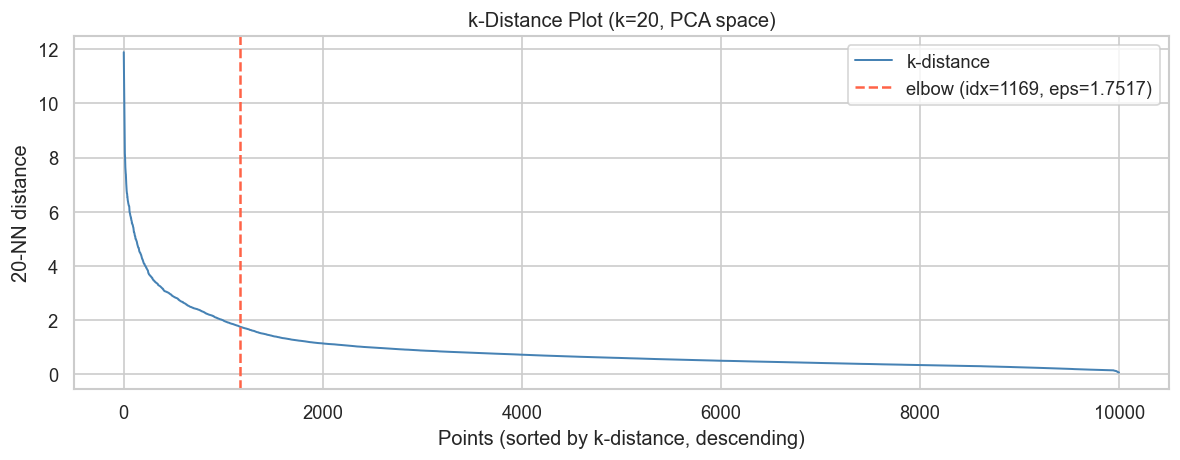

Saved: reports/figures/final_dbscan_kdistance.png



DBSCAN in PCA space (eps=1.7517, min_samples=20):
  n_clusters (excl. noise) : 7
  Noise points             : 829 (8.29%)
  Silhouette (non-noise)   : 0.3715
  ARI vs K-Means k=2 (non-noise): 0.9587
  AMI vs K-Means k=2 (non-noise): 0.7993

Cluster distribution:
  noise       : 829 (8.29%)
  cluster 0   : 8,379 (83.79%)
  cluster 1   : 190 (1.90%)
  cluster 2   : 155 (1.55%)
  cluster 3   : 321 (3.21%)
  cluster 4   : 69 (0.69%)
  cluster 5   : 25 (0.25%)
  cluster 6   : 32 (0.32%)


In [18]:
_X_samp = X_pca_sample.to_numpy(dtype=np.float64)
_dbscan_ms = 2 * n_comp          # min_samples = 2 x number of PCA components
print(f"DBSCAN parameters: min_samples = 2 x {n_comp} PCA components = {_dbscan_ms}")

# k-distance curve (distances to the min_samples-th nearest neighbor)
_nbrs  = NearestNeighbors(n_neighbors=_dbscan_ms).fit(_X_samp)
_dists, _ = _nbrs.kneighbors(_X_samp)
_kdists = np.sort(_dists[:, -1])[::-1]          # descending

# Geometric elbow: normalize both axes to [0, 1], maximise perpendicular distance to diagonal
_n_pts  = len(_kdists)
_x_norm = np.linspace(0.0, 1.0, _n_pts)
_y_min, _y_max = _kdists.min(), _kdists.max()
_y_norm = (_kdists - _y_min) / (_y_max - _y_min) if _y_max > _y_min else np.zeros(_n_pts)

_p1 = np.array([_x_norm[0],  _y_norm[0]])       # (0, 1)
_p2 = np.array([_x_norm[-1], _y_norm[-1]])       # (1, 0)
_line = _p2 - _p1
_line_len = np.linalg.norm(_line)
_vecs = np.column_stack([_x_norm, _y_norm]) - _p1
_perp = np.abs(_vecs[:, 0] * _line[1] - _vecs[:, 1] * _line[0]) / _line_len
_elbow_idx = int(np.argmax(_perp))
_eps_auto = float(_kdists[_elbow_idx])

print(f"eps (geometric elbow, index {_elbow_idx}): {_eps_auto:.4f}")
print()

# Figure: k-distance curve with elbow marked
_fig_kd, _ax_kd = plt.subplots(figsize=(10, 4))
_ax_kd.plot(_kdists, linewidth=1.2, color="steelblue", label="k-distance")
_ax_kd.axvline(_elbow_idx, color="tomato", linestyle="--",
               label=f"elbow (idx={_elbow_idx}, eps={_eps_auto:.4f})")
_ax_kd.set_xlabel("Points (sorted by k-distance, descending)")
_ax_kd.set_ylabel(f"{_dbscan_ms}-NN distance")
_ax_kd.set_title(f"k-Distance Plot (k={_dbscan_ms}, PCA space)")
_ax_kd.legend()
plt.tight_layout()
_fig_kd_path = FIGURES_DIR / f"{FIG_PREFIX}dbscan_kdistance.png"
_fig_kd.savefig(_fig_kd_path, bbox_inches="tight")
plt.show()
print(f"Saved: {_fig_kd_path.relative_to(PROJECT_ROOT)}")
print()

# Run DBSCAN with selected parameters
_db = DBSCAN(eps=_eps_auto, min_samples=_dbscan_ms, n_jobs=-1)
_db_labels = _db.fit_predict(_X_samp)

_n_db_cl   = len(set(_db_labels)) - (1 if -1 in _db_labels else 0)
_n_db_ns   = int((_db_labels == -1).sum())
_pct_db_ns = _n_db_ns / len(_db_labels) * 100
_mask_nn   = _db_labels != -1

if _n_db_cl >= 2 and _mask_nn.sum() > 10:
    _sil_db = silhouette_score(_X_samp[_mask_nn], _db_labels[_mask_nn],
                               sample_size=min(10_000, int(_mask_nn.sum())),
                               random_state=RANDOM_STATE)
else:
    _sil_db = float("nan")

_ari_db_km2 = adjusted_rand_score(labels_sample_k2[_mask_nn], _db_labels[_mask_nn])
_ami_db_km2 = adjusted_mutual_info_score(labels_sample_k2[_mask_nn], _db_labels[_mask_nn])

print(f"DBSCAN in PCA space (eps={_eps_auto:.4f}, min_samples={_dbscan_ms}):")
print(f"  n_clusters (excl. noise) : {_n_db_cl}")
print(f"  Noise points             : {_n_db_ns:,} ({_pct_db_ns:.2f}%)")
if not np.isnan(_sil_db):
    print(f"  Silhouette (non-noise)   : {_sil_db:.4f}")
else:
    print("  Silhouette: not computable (fewer than 2 clusters among non-noise)")
print(f"  ARI vs K-Means k=2 (non-noise): {_ari_db_km2:.4f}")
print(f"  AMI vs K-Means k=2 (non-noise): {_ami_db_km2:.4f}")
print()
print("Cluster distribution:")
for _lbl_v in sorted(set(_db_labels)):
    _n_v = int((_db_labels == _lbl_v).sum())
    _tag = "noise" if _lbl_v == -1 else f"cluster {_lbl_v}"
    print(f"  {_tag:<12s}: {_n_v:,} ({_n_v / len(_db_labels) * 100:.2f}%)")

In [19]:
# Sensitivity of DBSCAN to eps: factors 0.8, 1.0, 1.2 around the auto eps
_sens_rows = []
for _factor in [0.8, 1.0, 1.2]:
    _eps_t = _eps_auto * _factor
    _lbl_t = DBSCAN(eps=_eps_t, min_samples=_dbscan_ms, n_jobs=-1).fit_predict(_X_samp)
    _n_cl_t  = len(set(_lbl_t)) - (1 if -1 in _lbl_t else 0)
    _n_ns_t  = int((_lbl_t == -1).sum())
    _pct_t   = _n_ns_t / len(_lbl_t) * 100
    _mask_t  = _lbl_t != -1
    if _n_cl_t >= 2 and _mask_t.sum() > 10:
        _sil_t = silhouette_score(_X_samp[_mask_t], _lbl_t[_mask_t],
                                   sample_size=min(10_000, int(_mask_t.sum())),
                                   random_state=RANDOM_STATE)
    else:
        _sil_t = float("nan")
    _sens_rows.append({
        "eps_factor": _factor,
        "eps":        round(_eps_t, 4),
        "n_clusters": _n_cl_t,
        "noise_pct":  round(_pct_t, 2),
        "silhouette": round(_sil_t, 4) if not np.isnan(_sil_t) else float("nan"),
    })

_sens_df = pd.DataFrame(_sens_rows)
print(f"DBSCAN sensitivity grid (min_samples={_dbscan_ms}, eps varied):")
print(_sens_df.to_string(index=False))

DBSCAN sensitivity grid (min_samples=20, eps varied):
 eps_factor    eps  n_clusters  noise_pct  silhouette
        0.8 1.4013           7      11.07      0.3707
        1.0 1.7517           7       8.29      0.3715
        1.2 2.1020           4       6.20      0.3444


### What DBSCAN shows in the PCA space

In the PCA space DBSCAN keeps one dominant dense core, the residential majority, and separates
several small dense pockets within the non residential minority, with a noise fraction well
below that of the earlier full space run. The exact figures are printed above. Its agreement
with the K-Means k=2 split on non noise points is high, so the primary residential versus non
residential division is confirmed by an independent method. Beyond that split, DBSCAN adds
granularity that K-Means cannot, since K-Means is forced to a fixed k. The sensitivity grid
shows that the number of small pockets shifts with eps, so this fine structure is read as
indicative evidence of sub structure within the non residential minority, not as a definitive
cluster count. The stable, reportable conclusions are the dominant residential core, the reduced
noise, and the agreement with K-Means on the main split.

### 6.3 Hierarchical Clustering (visualization aid)

Hierarchical clustering is included here as a visualization aid, not as a third decision
algorithm. Agglomerative clustering starts with every point as its own cluster and merges the
closest clusters step by step, recording the sequence of merges as a dendrogram. Cutting the
tree at different heights yields different numbers of clusters, which makes the nested structure
of the data explicit: the height at which two groups merge shows how distinct they are. This is
exactly the view needed to justify the move from the robust k=2 split to the interpretive k=5
segmentation. Ward linkage is used because it merges the pair of clusters that least increases
within cluster variance, the same objective family as K-Means, so the two methods are
comparable and the dendrogram corroborates the K-Means partitions rather than introducing an
unrelated criterion.

Computing Ward linkage: 10,000 points x 10 PCA components


Linkage complete. Z shape: (9999, 4)
Top 5 merge heights: [114.9823, 119.8948, 133.3895, 190.8424, 235.1448]



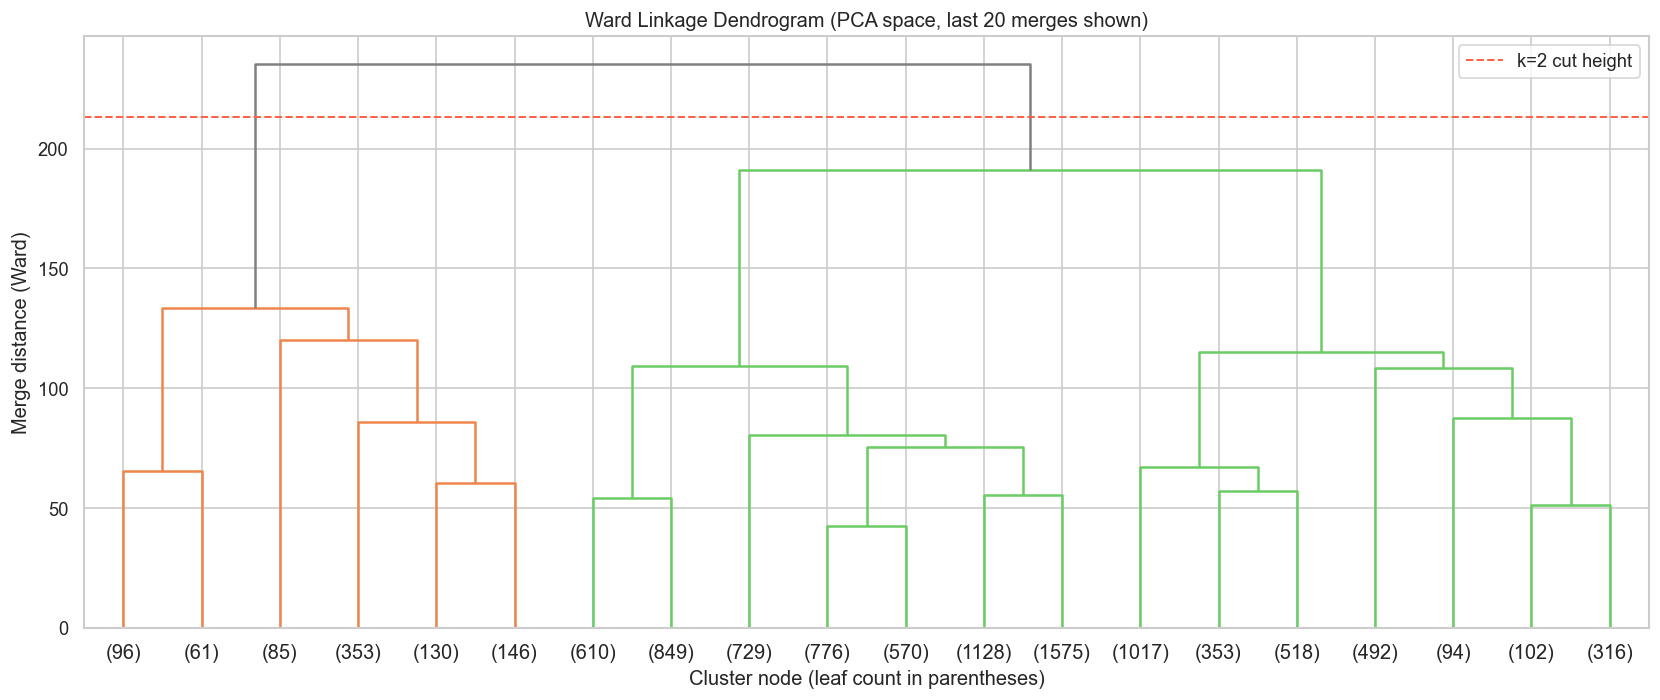

Saved: reports/figures/final_ward_dendrogram.png


In [20]:
# Ward linkage on the full 10,000-row PCA sample
_X_ward = X_pca_sample.to_numpy(dtype=np.float64)
print(f"Computing Ward linkage: {_X_ward.shape[0]:,} points x {_X_ward.shape[1]} PCA components")
Z = linkage(_X_ward, method="ward")
print(f"Linkage complete. Z shape: {Z.shape}")
print(f"Top 5 merge heights: {np.round(Z[-5:, 2], 4).tolist()}")
print()

# Color threshold: midpoint between the last two merges highlights the two main branches
_color_thresh = (Z[-1, 2] + Z[-2, 2]) / 2

_fig_dend, _ax_dend = plt.subplots(figsize=(14, 6))
dendrogram(
    Z,
    truncate_mode="lastp",
    p=20,
    color_threshold=_color_thresh,
    above_threshold_color="gray",
    ax=_ax_dend,
)
_ax_dend.axhline(_color_thresh, color="tomato", linestyle="--", linewidth=1.2,
                 label="k=2 cut height")
_ax_dend.set_title("Ward Linkage Dendrogram (PCA space, last 20 merges shown)")
_ax_dend.set_xlabel("Cluster node (leaf count in parentheses)")
_ax_dend.set_ylabel("Merge distance (Ward)")
_ax_dend.legend()
plt.tight_layout()
_fig_dend_path = FIGURES_DIR / f"{FIG_PREFIX}ward_dendrogram.png"
_fig_dend.savefig(_fig_dend_path, bbox_inches="tight")
plt.show()
print(f"Saved: {_fig_dend_path.relative_to(PROJECT_ROOT)}")

In [21]:
# Cut the tree at k=2 and k=5, compare with K-Means labels
_ward_cut2 = fcluster(Z, 2, criterion="maxclust")
_ward_cut5 = fcluster(Z, 5, criterion="maxclust")

_ari_w2_km2 = adjusted_rand_score(labels_sample_k2, _ward_cut2)
_ari_w5_km5 = adjusted_rand_score(labels_sample_k5, _ward_cut5)

print("Ward cut at k=2:")
_u2, _c2 = np.unique(_ward_cut2, return_counts=True)
for _u, _c in zip(_u2.tolist(), _c2.tolist()):
    print(f"  Ward cluster {_u}: {_c:,} ({_c / len(_ward_cut2) * 100:.2f}%)")
print(f"  ARI vs K-Means k=2: {_ari_w2_km2:.4f}")
print()

print("Ward cut at k=5:")
_u5, _c5 = np.unique(_ward_cut5, return_counts=True)
for _u, _c in zip(_u5.tolist(), _c5.tolist()):
    print(f"  Ward cluster {_u}: {_c:,} ({_c / len(_ward_cut5) * 100:.2f}%)")
print(f"  ARI vs K-Means k=5: {_ari_w5_km5:.4f}")

Ward cut at k=2:
  Ward cluster 1: 871 (8.71%)
  Ward cluster 2: 9,129 (91.29%)
  ARI vs K-Means k=2: 0.6321

Ward cut at k=5:
  Ward cluster 1: 157 (1.57%)
  Ward cluster 2: 85 (0.85%)
  Ward cluster 3: 629 (6.29%)
  Ward cluster 4: 6,237 (62.37%)
  Ward cluster 5: 2,892 (28.92%)
  ARI vs K-Means k=5: 0.5271


### What the dendrogram shows
The dendrogram displays the building stock as a nested hierarchy. The highest merge joins two
broad branches, which correspond to the residential versus non residential split found by
K-Means at k=2. Lower down, each branch subdivides into finer typologies, and a cut at five
clusters separates the residential branch and the non residential branch into their sub types.

The agreement scores printed above are moderate rather than high: the Ward cut at two and the
K-Means k=2 partition recover the same macro structure, a single large residential group and a
smaller non residential minority, but they place the exact boundary differently (the Ward cut is
close to nine versus ninety one percent, the K-Means split is close to fifteen versus eighty
five percent). This is expected. K-Means minimizes variance around centroids and favors
compact, roughly spherical groups, while Ward merges clusters agglomeratively, so the two
methods draw the boundary through the ambiguous mixed use lots at slightly different places. The
Adjusted Rand Index is sensitive to these boundary disagreements even when the overall structure
matches, and it decreases further at k=5 because finer partitions multiply boundary cases and
because k=5 is itself a low silhouette, interpretive partition.

The takeaway is therefore qualitative, which is all that is asked of a visualization aid: an
independent method built on a different procedure recovers the same two level organization, a
dominant residential mass that subdivides and a non residential minority that subdivides. This
supports the robustness of the primary split and the reasonableness of the five way interpretive
segmentation, without claiming point by point equivalence between the two methods. Hierarchical
clustering is used here only to visualize this nesting, not to select the final partition.

## Section 7: Cluster Evaluation and Visualization

This section evaluates the clustering before interpreting it. Three questions are addressed:
how strong each partition is on an internal metric, whether the algorithms agree on the same
groups, and what the clusters look like in a low dimensional view. All evaluation uses the PCA
space in which the clustering was performed, on the shared working sample.

### 7.1 Internal validity and method agreement

In [22]:
_lbl_k2_s = companion_sample["cluster_k2"].to_numpy()
_lbl_k5_s = companion_sample["cluster_k5"].to_numpy()
_X_ev = X_pca_sample.to_numpy(dtype=np.float64)

_sil_k2 = silhouette_score(_X_ev, _lbl_k2_s, random_state=RANDOM_STATE)
_sil_k5 = silhouette_score(_X_ev, _lbl_k5_s, random_state=RANDOM_STATE)

print("Silhouette scores on the 10,000-row PCA sample:")
print(f"  K-Means k=2  :  {_sil_k2:.4f}")
print(f"  K-Means k=5  :  {_sil_k5:.4f}")
print(f"  Difference (k=2 minus k=5)  :  {_sil_k2 - _sil_k5:.4f}")

Silhouette scores on the 10,000-row PCA sample:
  K-Means k=2  :  0.4734
  K-Means k=5  :  0.2193
  Difference (k=2 minus k=5)  :  0.2541


In [23]:
# Recompute DBSCAN in PCA space (geometric elbow, same as Section 6.2)
_X_ev = X_pca_sample.to_numpy(dtype=np.float64)
_ms_ev = 2 * n_comp

_nbrs_ev = NearestNeighbors(n_neighbors=_ms_ev).fit(_X_ev)
_dists_ev, _ = _nbrs_ev.kneighbors(_X_ev)
_kdists_ev = np.sort(_dists_ev[:, -1])[::-1]

_xn = np.linspace(0.0, 1.0, len(_kdists_ev))
_ym, _yM = _kdists_ev.min(), _kdists_ev.max()
_yn = (_kdists_ev - _ym) / (_yM - _ym) if _yM > _ym else np.zeros(len(_kdists_ev))
_p1e = np.array([_xn[0], _yn[0]]); _p2e = np.array([_xn[-1], _yn[-1]])
_le = _p2e - _p1e; _le_len = np.linalg.norm(_le)
_ve = np.column_stack([_xn, _yn]) - _p1e
_pe = np.abs(_ve[:, 0] * _le[1] - _ve[:, 1] * _le[0]) / _le_len
_eps_ev = float(_kdists_ev[int(np.argmax(_pe))])

_db_ev_labels = DBSCAN(eps=_eps_ev, min_samples=_ms_ev, n_jobs=-1).fit_predict(_X_ev)
_mask_nn_ev = _db_ev_labels != -1
_n_nn_ev = int(_mask_nn_ev.sum())

# Ward linkage: reuse Z from Section 6.3 if still in namespace, else recompute
try:
    _Z_ev = Z
    _ward_src = "reused from Section 6.3"
except NameError:
    _Z_ev = linkage(_X_ev, method="ward")
    _ward_src = "recomputed"

_w2_ev = fcluster(_Z_ev, 2, criterion="maxclust")
_w5_ev = fcluster(_Z_ev, 5, criterion="maxclust")

_lbl_k2_s = companion_sample["cluster_k2"].to_numpy()
_lbl_k5_s = companion_sample["cluster_k5"].to_numpy()

_ari_km2_db  = adjusted_rand_score(_lbl_k2_s[_mask_nn_ev], _db_ev_labels[_mask_nn_ev])
_ari_w2_km2  = adjusted_rand_score(_lbl_k2_s, _w2_ev)
_ari_w5_km5  = adjusted_rand_score(_lbl_k5_s, _w5_ev)

print(f"DBSCAN: eps={_eps_ev:.4f}, min_samples={_ms_ev}")
print(f"Non-noise points used for K-Means vs DBSCAN comparison: {_n_nn_ev:,} / {len(_db_ev_labels):,}")
print(f"Ward linkage matrix: {_ward_src}")
print()
print("Inter-method agreement (Adjusted Rand Index, PCA space, 10,000-row sample):")
print(f"  K-Means k=2  vs  DBSCAN (non-noise)  :  {_ari_km2_db:.4f}")
print(f"  Ward(cut=2)  vs  K-Means k=2         :  {_ari_w2_km2:.4f}")
print(f"  Ward(cut=5)  vs  K-Means k=5         :  {_ari_w5_km5:.4f}")

DBSCAN: eps=1.7517, min_samples=20
Non-noise points used for K-Means vs DBSCAN comparison: 9,171 / 10,000
Ward linkage matrix: reused from Section 6.3

Inter-method agreement (Adjusted Rand Index, PCA space, 10,000-row sample):
  K-Means k=2  vs  DBSCAN (non-noise)  :  0.9587
  Ward(cut=2)  vs  K-Means k=2         :  0.6321
  Ward(cut=5)  vs  K-Means k=5         :  0.5271


### Reading the evaluation
The silhouette score is highest for the two cluster partition, which confirms that k=2 is the
statistically strongest division and the robust primary result. The five cluster partition has a
lower silhouette, as printed above, which is expected and openly acknowledged: k=5 is an
interpretive segmentation chosen to answer the research question, not the metric optimum.

On method agreement, K-Means and DBSCAN agree closely on the primary split (high ARI on non
noise points), so an independent density based method confirms the residential versus non
residential division. Ward agrees at a moderate level, recovering the same two level macro
structure while drawing the fine boundaries slightly differently, consistent with Section 6.3.
The convergence of three different procedures on the same broad organization is the main
evaluation result.

### 7.2 Visualization of the clusters

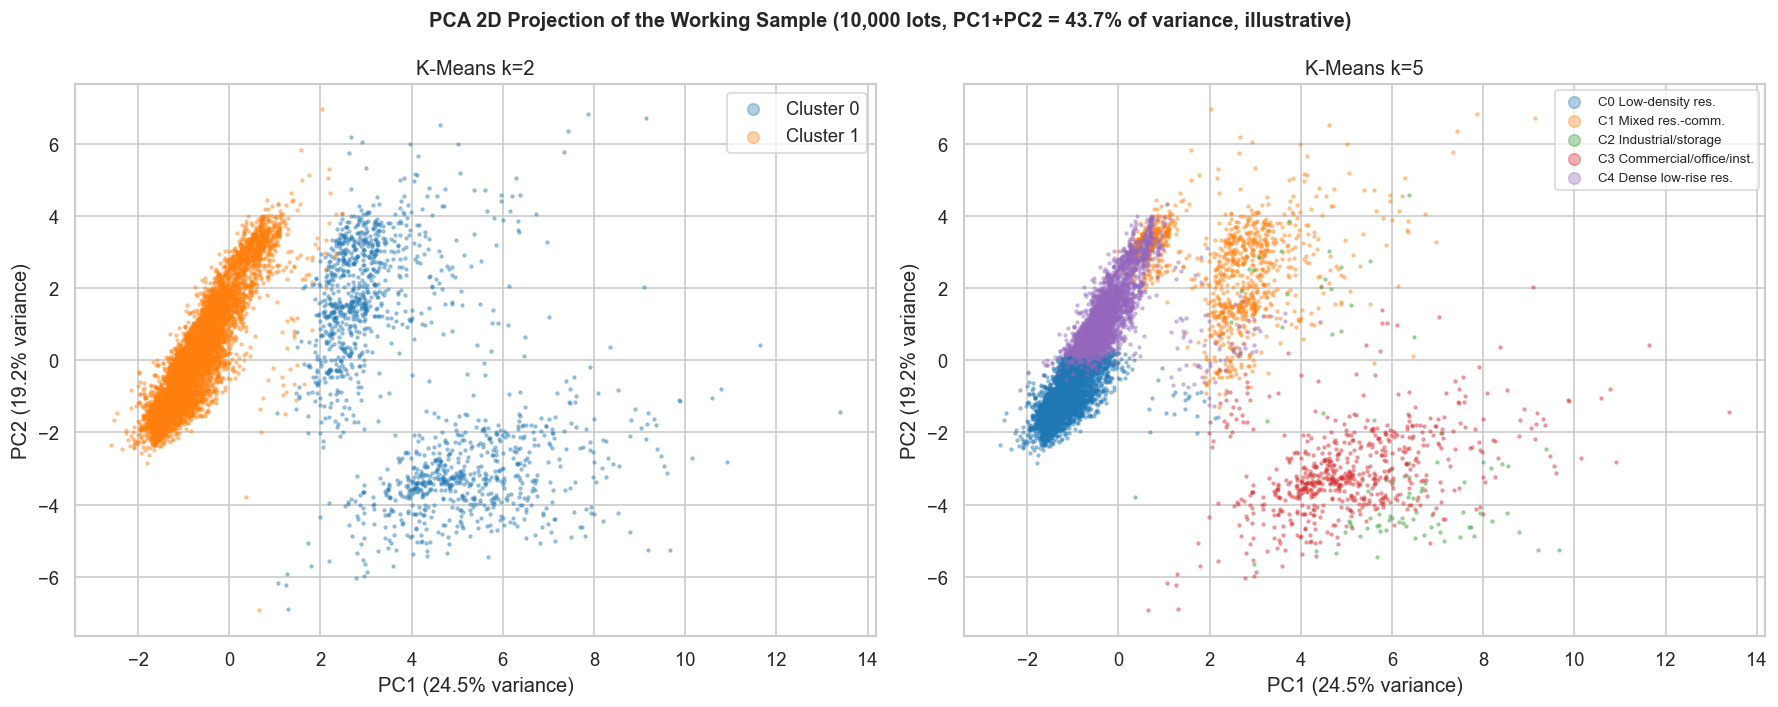

Saved: reports/figures/final_eval_pca_2d.png
PC1: 24.49%  PC2: 19.20%  combined: 43.70%


In [24]:
_pc1_var = pca.explained_variance_ratio_[0] * 100
_pc2_var = pca.explained_variance_ratio_[1] * 100
_combined_var = _pc1_var + _pc2_var

_pc1_arr = X_pca_sample["PC1"].to_numpy()
_pc2_arr = X_pca_sample["PC2"].to_numpy()
_lbl_k2_s = companion_sample["cluster_k2"].to_numpy()
_lbl_k5_s = companion_sample["cluster_k5"].to_numpy()

_pal = sns.color_palette("tab10", 5)

_fig_2d, (_ax2, _ax5) = plt.subplots(1, 2, figsize=(15, 6))
_fig_2d.suptitle(
    f"PCA 2D Projection of the Working Sample (10,000 lots, PC1+PC2 = {_combined_var:.1f}% of variance, illustrative)",
    fontsize=12, fontweight="bold",
)

# Left: k=2
for _cl in sorted(np.unique(_lbl_k2_s)):
    _m = _lbl_k2_s == _cl
    _ax2.scatter(_pc1_arr[_m], _pc2_arr[_m],
                 color=_pal[_cl], s=3, alpha=0.35, label=f"Cluster {_cl}")
_ax2.set_xlabel(f"PC1 ({_pc1_var:.1f}% variance)")
_ax2.set_ylabel(f"PC2 ({_pc2_var:.1f}% variance)")
_ax2.set_title("K-Means k=2")
_ax2.legend(markerscale=4, framealpha=0.75)

# Right: k=5
_k5_names = {
    0: "C0 Low-density res.",
    1: "C1 Mixed res.-comm.",
    2: "C2 Industrial/storage",
    3: "C3 Commercial/office/inst.",
    4: "C4 Dense low-rise res.",
}
for _cl in sorted(np.unique(_lbl_k5_s)):
    _m = _lbl_k5_s == _cl
    _ax5.scatter(_pc1_arr[_m], _pc2_arr[_m],
                 color=_pal[_cl], s=3, alpha=0.35, label=_k5_names[_cl])
_ax5.set_xlabel(f"PC1 ({_pc1_var:.1f}% variance)")
_ax5.set_ylabel(f"PC2 ({_pc2_var:.1f}% variance)")
_ax5.set_title("K-Means k=5")
_ax5.legend(markerscale=4, framealpha=0.75, fontsize=8)

plt.tight_layout()
_fig_2d_path = FIGURES_DIR / f"{FIG_PREFIX}eval_pca_2d.png"
_fig_2d.savefig(_fig_2d_path, bbox_inches="tight")
plt.show()
print(f"Saved: {_fig_2d_path.relative_to(PROJECT_ROOT)}")
print(f"PC1: {_pc1_var:.2f}%  PC2: {_pc2_var:.2f}%  combined: {_combined_var:.2f}%")

Running t-SNE on the 10,000-row PCA sample (perplexity=30, init=pca)...


t-SNE done.



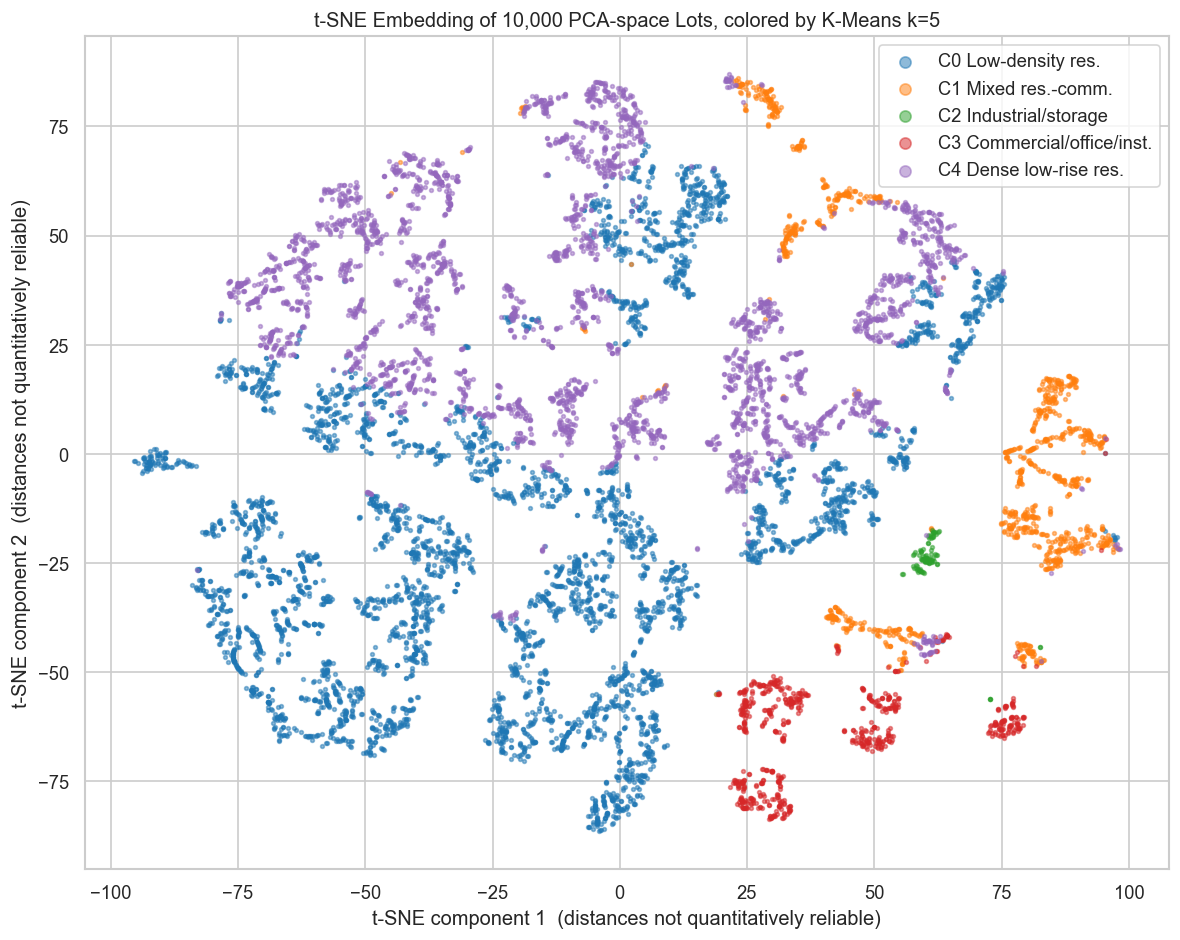

Saved: reports/figures/final_eval_tsne.png


In [25]:
from sklearn.manifold import TSNE as _TSNE

print("Running t-SNE on the 10,000-row PCA sample (perplexity=30, init=pca)...")
_tsne_model = _TSNE(n_components=2, perplexity=30, init="pca",
                    learning_rate="auto", random_state=RANDOM_STATE)
_X_tsne = _tsne_model.fit_transform(X_pca_sample.to_numpy(dtype=np.float64))
print("t-SNE done.")
print()

_lbl_k5_s = companion_sample["cluster_k5"].to_numpy()
_pal_t = sns.color_palette("tab10", 5)
_k5_names_t = {
    0: "C0 Low-density res.",
    1: "C1 Mixed res.-comm.",
    2: "C2 Industrial/storage",
    3: "C3 Commercial/office/inst.",
    4: "C4 Dense low-rise res.",
}

_fig_tsne, _ax_tsne = plt.subplots(figsize=(10, 8))
for _cl in sorted(np.unique(_lbl_k5_s)):
    _m = _lbl_k5_s == _cl
    _ax_tsne.scatter(_X_tsne[_m, 0], _X_tsne[_m, 1],
                     color=_pal_t[_cl], s=5, alpha=0.5, label=_k5_names_t[_cl])
_ax_tsne.set_xlabel("t-SNE component 1  (distances not quantitatively reliable)")
_ax_tsne.set_ylabel("t-SNE component 2  (distances not quantitatively reliable)")
_ax_tsne.set_title("t-SNE Embedding of 10,000 PCA-space Lots, colored by K-Means k=5")
_ax_tsne.legend(markerscale=3, framealpha=0.8)
plt.tight_layout()
_fig_tsne_path = FIGURES_DIR / f"{FIG_PREFIX}eval_tsne.png"
_fig_tsne.savefig(_fig_tsne_path, bbox_inches="tight")
plt.show()
print(f"Saved: {_fig_tsne_path.relative_to(PROJECT_ROOT)}")

### What the visualizations show
The two dimensional PCA projection separates the residential mass from the non residential
groups along the first component, which Section 5 identified as the use mix axis. The five
cluster coloring shows the residential mass split by density and the non residential mass split
into its functional sub types. These projections retain only part of the total variance, so they
illustrate the structure rather than define it; the cluster count was fixed by metrics, not by
visual inspection.

The t-SNE embedding, colored by the K-Means k=5 labels, shows the same groups as locally
coherent regions. t-SNE is used here only to visualize the clusters found in the representation
space. Distances between groups, their sizes, and the empty space between them in a t-SNE plot
are not quantitatively reliable, so no clustering decision is based on this view.

### 7.3 Which method to recommend

K-Means is the recommended primary method for this dataset. It assigns every lot to exactly one
group, which yields a complete and stable segmentation that is easy to describe and reproduce,
and it produces the highest silhouette at k=2. Its limitation is that it requires the number of
clusters in advance and assumes roughly convex groups, which is why it is paired with two checks.
DBSCAN is valuable as an independent density based confirmation and for surfacing fine sub
structure within the non residential minority, at the cost of sensitivity to its density
threshold. Hierarchical clustering with Ward linkage contributes the dendrogram, which makes the
nested two level organization visible and supports the interpretive move to five typologies. The
reported segmentation therefore rests on K-Means, validated by the agreement of DBSCAN and Ward.

## Section 8: Cluster Interpretation

### 8.1 The five building typologies

In [26]:
# Median of each original feature by cluster_k5
_profile_rows = []
for _cl in range(5):
    _sub = companion[companion["cluster_k5"] == _cl]
    _n = len(_sub)
    _row = {"cluster": _cl, "n": _n, "pct": round(_n / len(companion) * 100, 2)}
    for _f in feature_names:
        _row[_f] = round(_sub[_f].median(), 4)
    _profile_rows.append(_row)

profile_df = pd.DataFrame(_profile_rows).set_index("cluster")

pd.set_option("display.max_columns", 25)
pd.set_option("display.width", 200)
print("K-Means k=5: Cluster Median Profiles (original feature units, pre-standardization)")
print()
print(profile_df.round(2).to_string())

K-Means k=5: Cluster Median Profiles (original feature units, pre-standardization)

              n    pct  lotarea  bldgarea  numfloors  lotfront  lotdepth  unitstotal  unitsres  resarea  comarea  officearea  retailarea  garagearea  strgearea  building_age  building_density  residential_ratio
cluster                                                                                                                                                                                                           
0        334240  48.97   2600.0    1584.0        2.0      33.0     100.0         1.0       1.0   1426.0      0.0         0.0         0.0         0.0        0.0          76.0              0.60                1.0
1         70941  10.39   3025.0    5592.5        4.0      90.0     106.0         3.5       7.0   4354.0   1120.0         0.0       960.0         0.0        0.0          98.0              1.26                1.0
2          7028   1.03   6119.0    5592.5        2.0     125.0     161.0

Land-use composition by cluster (%, post-hoc -- landuse was never a clustering input):

cluster                                 0      1      2      3      4
1 One & Two Family                  99.03   0.03   0.06   0.01  47.98
2 Multi-Family Walk-Up               0.68  19.74   2.59   0.00  49.29
3 Multi-Family Elevator              0.00  16.66   4.81   0.02   0.32
4 Mixed Res. & Commercial            0.25  62.27  23.94   8.55   2.27
5 Commercial & Office                0.00   0.37  16.13  42.23   0.01
6 Industrial & Manufacturing         0.00   0.09  45.58  13.08   0.03
7 Transportation & Utility           0.00   0.04   2.48   7.46   0.00
8 Public Facilities & Institutions   0.03   0.78   3.08  23.93   0.10
9 Open Space & Outdoor Recreation    0.00   0.00   0.39   1.68   0.00
10 Parking Facilities                0.00   0.01   0.94   3.04   0.00
11 Vacant Land                       0.00   0.00   0.00   0.00   0.00



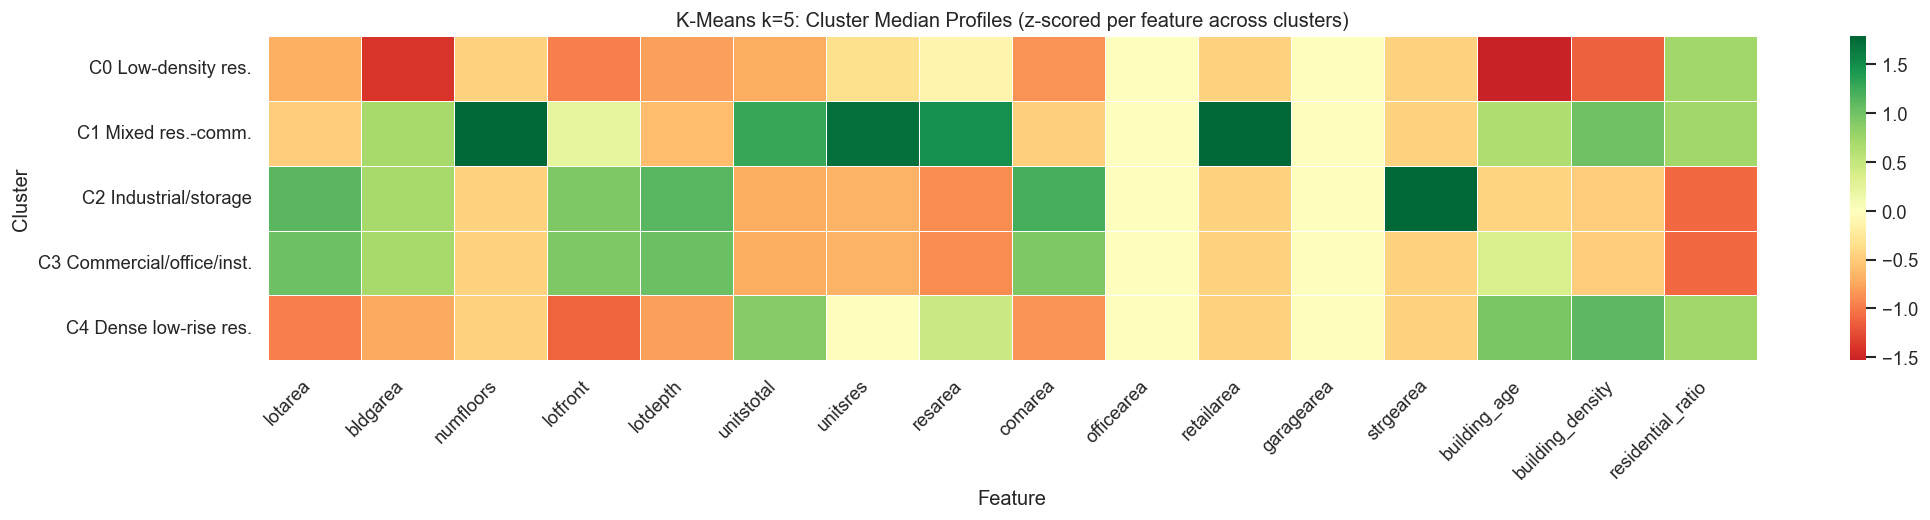

Saved: reports/figures/final_cluster_profiles.png


In [27]:
# Official PLUTO landuse code dictionary
_LANDUSE_MAP = {
    1:  "1 One & Two Family",
    2:  "2 Multi-Family Walk-Up",
    3:  "3 Multi-Family Elevator",
    4:  "4 Mixed Res. & Commercial",
    5:  "5 Commercial & Office",
    6:  "6 Industrial & Manufacturing",
    7:  "7 Transportation & Utility",
    8:  "8 Public Facilities & Institutions",
    9:  "9 Open Space & Outdoor Recreation",
    10: "10 Parking Facilities",
    11: "11 Vacant Land",
}

_lu_rows = []
for _cl in range(5):
    _sub = companion[companion["cluster_k5"] == _cl]
    _lu_int = _sub["landuse"].dropna().astype(int)
    _n_lu = max(len(_lu_int), 1)
    _row = {"cluster": _cl}
    for _code, _label in _LANDUSE_MAP.items():
        _cnt = (_lu_int == _code).sum()
        _row[_label] = round(_cnt / _n_lu * 100, 2)
    _lu_rows.append(_row)

lu_df = pd.DataFrame(_lu_rows).set_index("cluster")
print("Land-use composition by cluster (%, post-hoc -- landuse was never a clustering input):")
print()
pd.set_option("display.width", 220)
print(lu_df.T.to_string())
print()

# Heatmap: cluster medians z-scored per feature for visual comparability
_cl_labels = {
    0: "C0 Low-density res.",
    1: "C1 Mixed res.-comm.",
    2: "C2 Industrial/storage",
    3: "C3 Commercial/office/inst.",
    4: "C4 Dense low-rise res.",
}

_med_mat = profile_df[feature_names].copy()
_col_std = _med_mat.std(axis=0)
_col_std[_col_std == 0] = 1.0
_med_z = (_med_mat - _med_mat.mean(axis=0)) / _col_std
_med_z = _med_z.fillna(0.0)
_med_z.index = [_cl_labels[i] for i in range(5)]

_fig_prof, _ax_prof = plt.subplots(figsize=(18, 4.5))
sns.heatmap(
    _med_z,
    cmap="RdYlGn",
    center=0,
    linewidths=0.4,
    annot=False,
    ax=_ax_prof,
)
_ax_prof.set_title("K-Means k=5: Cluster Median Profiles (z-scored per feature across clusters)")
_ax_prof.set_xlabel("Feature")
_ax_prof.set_ylabel("Cluster")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
_fig_prof_path = FIGURES_DIR / f"{FIG_PREFIX}cluster_profiles.png"
_fig_prof.savefig(_fig_prof_path, bbox_inches="tight")
plt.show()
print(f"Saved: {_fig_prof_path.relative_to(PROJECT_ROOT)}")

Five building typologies emerge from the K-Means k=5 partition. The profile table (Code A)
shows the median value of each feature per cluster in original physical units. The land use
composition table (Code B) provides a blind post-hoc check: because land use was never used as
a clustering input, a strong correspondence between cluster membership and land use code
validates the typological reading without circularity.

**Cluster 0: Low-density residential.** This is the largest cluster by lot count. The profile
table shows that both median comarea and median retailarea are zero, and the residential ratio
is 1.0: these lots are exclusively residential. The median unit count per lot is close to one,
indicating standalone structures with small lot footprints and the lowest building density among
residential clusters. The land use composition is almost entirely code 1 (One and Two Family),
which serves as a blind confirmation of the typological reading.

**Cluster 4: Dense low-rise residential.** Cluster 4 shares the purely residential character of
cluster 0 (comarea = 0, residential ratio = 1.0) but is distinctly denser. The profile table
shows the narrowest median lot frontage of the five clusters, consistent with attached row
houses and walk-up buildings lining narrow blocks. Building density is higher than in cluster 0
and the median residential unit count is above one, reflecting shared structures. The land use
composition splits between codes 1 (One and Two Family) and 2 (Multi-Family Walk-Up), the two
codes that span this continuum from semi-detached to attached multi-family residential.

**Cluster 1: Mixed residential-commercial.** The profile table shows a positive median comarea
and retailarea, meaning the typical lot in this cluster includes commercial floor space alongside
housing. At the same time the residential ratio is 1.0. This is not a contradiction: the
residential ratio is computed as residential units divided by total units, not residential area
divided by total building area, and all the units in these buildings are residential even though
the floor plan includes commercial space. The typical configuration is ground-floor retail or
commercial with apartments above. The dominant land use code is Mixed Residential and Commercial
(code 4), which directly corroborates this reading as an independent blind check.

**Cluster 2: Industrial and storage.** This is the smallest cluster by lot count. Its defining
signature is the largest median storage area (strgearea) of the five clusters, as printed in
the profile table. The residential ratio is zero and the residential area is zero: no
residential units are present. Commercial area is positive but smaller than in cluster 3. The
land use composition is led by Industrial and Manufacturing (code 6), validating the industrial
and storage label.

**Cluster 3: Commercial, office and institutional.** Cluster 3 is also entirely non-residential
(residential ratio = 0, residential area = 0) but is distinguished from cluster 2 by a near-zero
median storage area (strgearea). Its median commercial area is large. The land use composition
is led by Commercial and Office (code 5) and Public Facilities and Institutions (code 8), with
a smaller share of Industrial and Manufacturing (code 6). The cluster combines commercial
parcels, office buildings, and public institutional uses such as schools and government
facilities.

### 8.2 What distinguishes the clusters

In [28]:
from sklearn.feature_selection import f_classif as _f_classif

# F-ratio ANOVA in the standardized space (the space in which clustering was performed)
_labels_k5 = companion["cluster_k5"].to_numpy()
_X_std = X_scaled.to_numpy(dtype=np.float64)

_F, _pval = _f_classif(_X_std, _labels_k5)

_f_df = pd.DataFrame({
    "feature":     feature_names,
    "F_statistic": np.round(_F, 1),
    "p_value":     _pval,
}).sort_values("F_statistic", ascending=False)

print("ANOVA F-statistic per feature (between-cluster / within-cluster variance, standardized space):")
print("  Computed on X_scaled (log1p + StandardScaler) with K-Means k=5 labels")
print("  Higher F = the feature separates the five typologies more strongly in the clustering space")
print()
print(_f_df.to_string(index=False))

ANOVA F-statistic per feature (between-cluster / within-cluster variance, standardized space):
  Computed on X_scaled (log1p + StandardScaler) with K-Means k=5 labels
  Higher F = the feature separates the five typologies more strongly in the clustering space

          feature  F_statistic  p_value
        strgearea    4913081.8      0.0
residential_ratio    1444977.5      0.0
          resarea    1254842.2      0.0
          comarea     644490.5      0.0
       unitstotal     208996.4      0.0
         unitsres     192384.5      0.0
         bldgarea     186151.4      0.0
 building_density     173208.6      0.0
       retailarea     144934.8      0.0
       officearea      49332.5      0.0
        numfloors      42698.6      0.0
          lotarea      36749.6      0.0
       garagearea      15119.5      0.0
     building_age      13899.5      0.0
         lotdepth      12526.2      0.0
         lotfront       7904.5      0.0


Feature importance is measured here in the standardized feature space, the same space in which
the clustering was performed. For each feature the ratio of between cluster to within cluster
variance (an ANOVA F statistic) quantifies how strongly it separates the five typologies. This
scale is the correct one: the raw area features are zero for most lots and have very long tails,
so a ranking computed on raw units would be dominated by their global spread and would understate
features such as commercial area and storage area. After the log1p transformation and
standardization used by the pipeline, all features are on a comparable footing.

The strongest separators, in order, are storage area (strgearea), residential ratio,
residential area (resarea), commercial area (comarea), and unit count (unitstotal). This is
consistent with the typology descriptions above: residential ratio and residential area separate
the residential typologies from the non residential ones, commercial area isolates the mixed and
commercial groups, and storage area is the single strongest separator overall because it is what
sets the industrial typology apart from all others, and in particular from the commercial and
institutional typology that shares its non residential character. Retail area contributes at a
moderate level, further distinguishing cluster 1 from the purely residential clusters. Office
area and garage area contribute little, since they are near zero across all five cluster medians.

### 8.3 Geographic distribution across boroughs

The research question asks how building typologies are structured across the boroughs of New
York City. Borough was deliberately excluded from the clustering input, so any association
between a typology and a borough is a discovery rather than a built-in assumption. The analysis
below uses the five typology partition as the primary lens, with the two group partition as a
simpler complement. Because the boroughs are very unequally represented in the dataset, all
tables are reported as within group percentages rather than raw counts, so that the dominance of
the larger boroughs does not distort the reading.

In [29]:
_BOR_ORDER = ["MN", "BK", "QN", "BX", "SI"]
_CL_NAMES = {
    0: "C0 Low-density res.",
    1: "C1 Mixed res.-comm.",
    2: "C2 Industrial/storage",
    3: "C3 Commercial/office/inst.",
    4: "C4 Dense low-rise res.",
}

_comp_bor = companion[companion["borough"].isin(_BOR_ORDER)].copy()

_ct = (_comp_bor.groupby(["borough", "cluster_k5"])
       .size().unstack(fill_value=0)
       .reindex(index=_BOR_ORDER, columns=[0, 1, 2, 3, 4], fill_value=0))

_ct_bor = _ct.div(_ct.sum(axis=1), axis=0) * 100
_ct_bor.columns = [_CL_NAMES[c] for c in [0, 1, 2, 3, 4]]

_overall_k5 = companion["cluster_k5"].value_counts(normalize=True).sort_index() * 100

print("Typology share within each borough, k=5 (%, rows sum to 100):")
print(_ct_bor.round(1).to_string())
print()
print("Overall typology share across the full dataset (% of all lots):")
for _cl in [0, 1, 2, 3, 4]:
    print(f"  {_CL_NAMES[_cl]}: {_overall_k5[_cl]:.1f}%")

Typology share within each borough, k=5 (%, rows sum to 100):
         C0 Low-density res.  C1 Mixed res.-comm.  C2 Industrial/storage  C3 Commercial/office/inst.  C4 Dense low-rise res.
borough                                                                                                                     
MN                       0.3                 47.7                    2.9                        17.8                    31.3
BK                      30.5                 11.3                    0.9                         6.1                    51.3
QN                      62.7                  6.4                    1.1                         5.7                    24.2
BX                      39.7                 11.8                    1.2                         8.8                    38.6
SI                      90.5                  1.6                    0.4                         3.8                     3.6

Overall typology share across the full dataset (% of all lots)

In [30]:
_ct_typ = _ct.div(_ct.sum(axis=0), axis=1) * 100
_ct_typ.columns = [_CL_NAMES[c] for c in [0, 1, 2, 3, 4]]
print("Location of each typology across boroughs, k=5 (%, columns sum to 100):")
print("(reads: of all lots of typology X, what share is in each borough)")
print()
print(_ct_typ.round(1).to_string())

Location of each typology across boroughs, k=5 (%, columns sum to 100):
(reads: of all lots of typology X, what share is in each borough)

         C0 Low-density res.  C1 Mixed res.-comm.  C2 Industrial/storage  C3 Commercial/office/inst.  C4 Dense low-rise res.
borough                                                                                                                     
MN                       0.0                 25.9                   16.0                        15.3                     5.3
BK                      22.4                 39.0                   30.7                        33.2                    56.0
QN                      42.7                 20.6                   35.2                        28.7                    24.4
BX                       8.8                 12.3                   12.2                        14.5                    12.7
SI                      26.0                  2.1                    5.9                         8.2           

In [31]:
_ct2 = (_comp_bor.groupby(["borough", "cluster_k2"])
        .size().unstack(fill_value=0)
        .reindex(index=_BOR_ORDER, columns=[0, 1], fill_value=0))
_ct2_bor = _ct2.div(_ct2.sum(axis=1), axis=0) * 100

# Identify which k=2 cluster is the larger (residential) group
_k2_sizes = companion["cluster_k2"].value_counts()
_res_cl   = int(_k2_sizes.idxmax())   # larger = residential
_nonr_cl  = 1 - _res_cl

_ct2_bor.columns = [
    f"cluster {c} ({'residential' if c == _res_cl else 'non-residential'})"
    for c in [0, 1]
]
print("K=2 partition within each borough (%, rows sum to 100):")
print(_ct2_bor.round(1).to_string())

K=2 partition within each borough (%, rows sum to 100):
         cluster 0 (non-residential)  cluster 1 (residential)
borough                                                      
MN                              55.4                     44.6
BK                              16.1                     83.9
QN                              11.8                     88.2
BX                              15.4                     84.6
SI                               5.6                     94.4


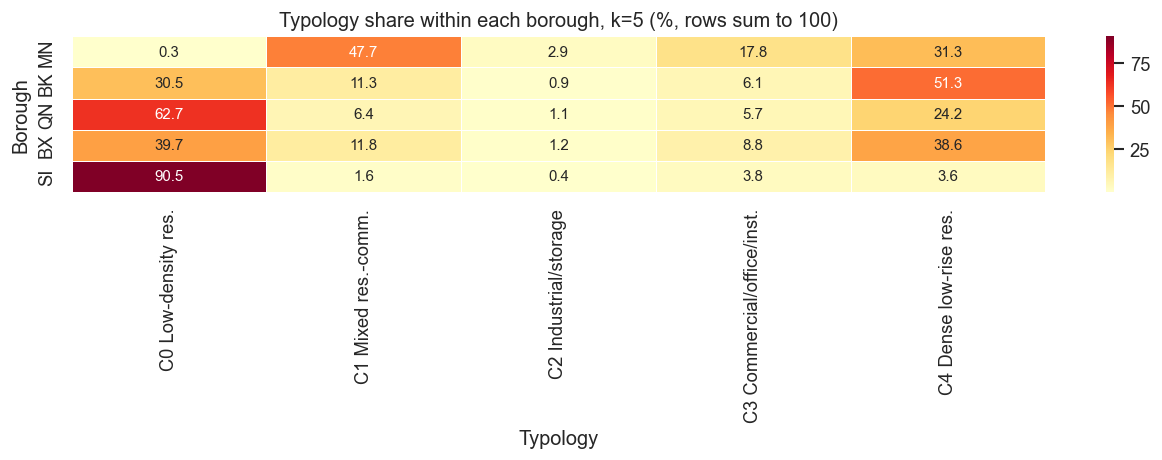

Saved: reports/figures/final_borough_heatmap.png


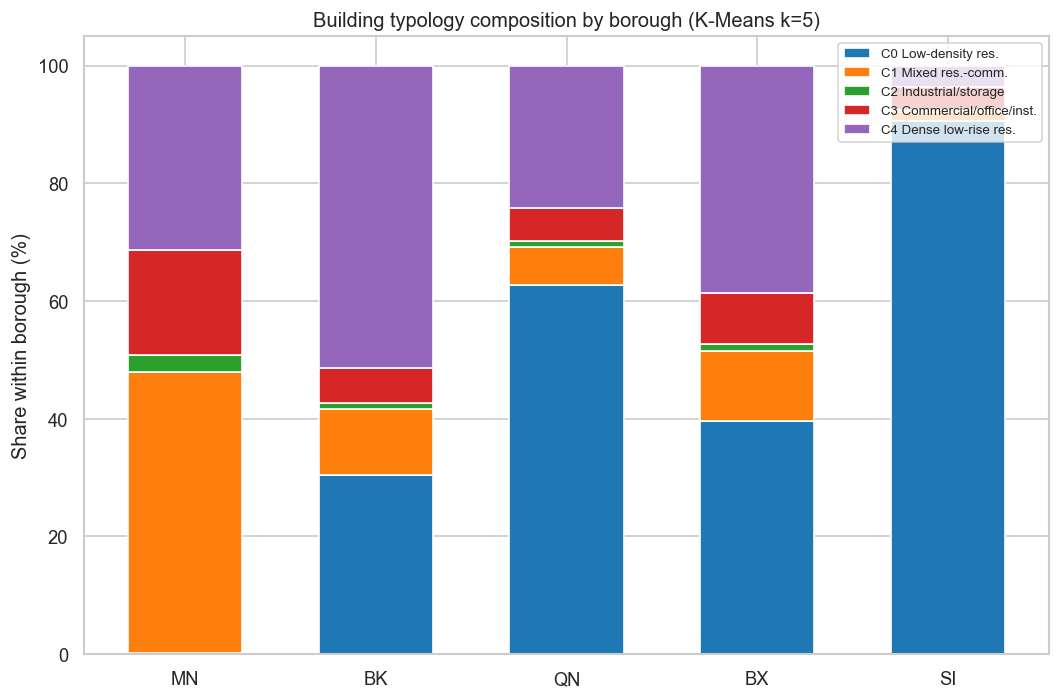

Saved: reports/figures/final_borough_stacked.png


In [32]:
_pal5 = sns.color_palette("tab10", 5)

# Heatmap of Code A table
_fig_hm, _ax_hm = plt.subplots(figsize=(11, 4))
sns.heatmap(
    _ct_bor.round(1),
    annot=True, fmt=".1f", cmap="YlOrRd",
    linewidths=0.5, ax=_ax_hm, annot_kws={"size": 9},
)
_ax_hm.set_title("Typology share within each borough, k=5 (%, rows sum to 100)")
_ax_hm.set_xlabel("Typology")
_ax_hm.set_ylabel("Borough")
plt.tight_layout()
_fig_hm_path = FIGURES_DIR / f"{FIG_PREFIX}borough_heatmap.png"
_fig_hm.savefig(_fig_hm_path, bbox_inches="tight")
plt.show()
print(f"Saved: {_fig_hm_path.relative_to(PROJECT_ROOT)}")

# Stacked bar
_cl_order = [0, 1, 2, 3, 4]
_fig_sb, _ax_sb = plt.subplots(figsize=(9, 6))
_bottom = np.zeros(len(_BOR_ORDER))
for _cl in _cl_order:
    _cname = _CL_NAMES[_cl]
    _vals  = _ct_bor[_cname].to_numpy()
    _ax_sb.bar(_BOR_ORDER, _vals, bottom=_bottom,
               color=_pal5[_cl], label=_cname, width=0.6)
    _bottom += _vals
_ax_sb.set_ylim(0, 105)
_ax_sb.set_ylabel("Share within borough (%)")
_ax_sb.set_title("Building typology composition by borough (K-Means k=5)")
_ax_sb.legend(loc="upper right", fontsize=8, framealpha=0.8)
plt.tight_layout()
_fig_sb_path = FIGURES_DIR / f"{FIG_PREFIX}borough_stacked.png"
_fig_sb.savefig(_fig_sb_path, bbox_inches="tight")
plt.show()
print(f"Saved: {_fig_sb_path.relative_to(PROJECT_ROOT)}")

Lots removed by geographic bounds filter (lat/lon outside NYC range): 129,526 of 682,515


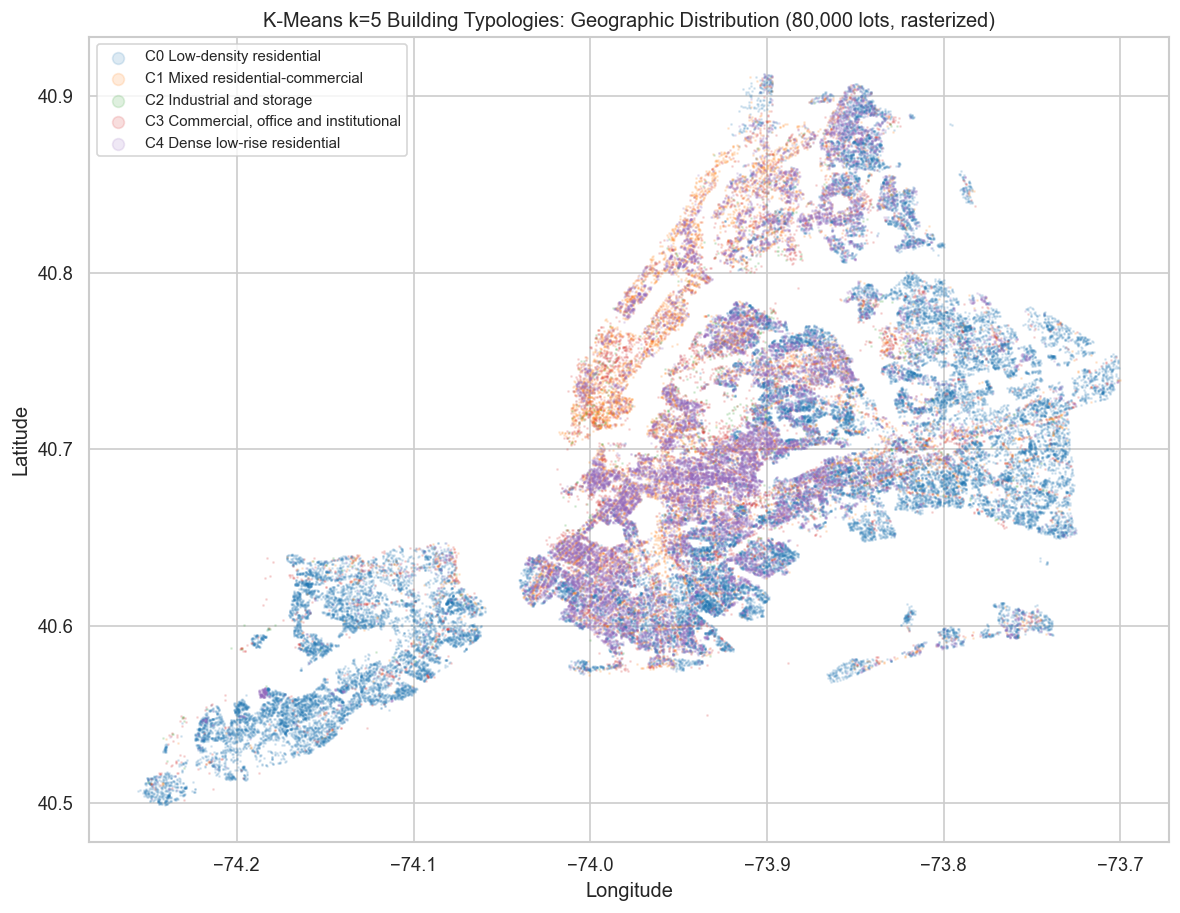

Saved: reports/figures/final_borough_map.png
Subsample: 80,000 of 552,989 valid lots


In [33]:
# lat/lon are stored as integers at 1e-7 scale; convert to degrees
_lat_arr = companion["latitude"].to_numpy(dtype=np.float64) * 1e-7
_lon_arr = companion["longitude"].to_numpy(dtype=np.float64) * 1e-7

_valid_geo = ((_lat_arr >= 40.4) & (_lat_arr <= 41.0) &
              (_lon_arr >= -74.3) & (_lon_arr <= -73.6))
_n_removed_geo = int((~_valid_geo).sum())
print(f"Lots removed by geographic bounds filter (lat/lon outside NYC range): {_n_removed_geo:,} of {len(companion):,}")

_lat_v   = _lat_arr[_valid_geo]
_lon_v   = _lon_arr[_valid_geo]
_lbl5_v  = companion["cluster_k5"].to_numpy()[_valid_geo]

_n_geo   = len(_lat_v)
_sub_geo = min(80_000, _n_geo)
_rng_geo = np.random.RandomState(RANDOM_STATE)
_sub_idx_geo = _rng_geo.choice(_n_geo, size=_sub_geo, replace=False)

_lat_p = _lat_v[_sub_idx_geo]
_lon_p = _lon_v[_sub_idx_geo]
_lbl_p = _lbl5_v[_sub_idx_geo]

_pal_geo = sns.color_palette("tab10", 5)
_geo_names = {
    0: "C0 Low-density residential",
    1: "C1 Mixed residential-commercial",
    2: "C2 Industrial and storage",
    3: "C3 Commercial, office and institutional",
    4: "C4 Dense low-rise residential",
}

_fig_map, _ax_map = plt.subplots(figsize=(10, 12))
for _cl in range(5):
    _m = _lbl_p == _cl
    _ax_map.scatter(_lon_p[_m], _lat_p[_m],
                    color=_pal_geo[_cl], s=0.5, alpha=0.15,
                    rasterized=True, label=_geo_names[_cl])
_ax_map.set_aspect("equal")
_ax_map.set_xlabel("Longitude")
_ax_map.set_ylabel("Latitude")
_ax_map.set_title(
    f"K-Means k=5 Building Typologies: Geographic Distribution ({_sub_geo:,} lots, rasterized)"
)
_ax_map.legend(markerscale=10, framealpha=0.8, fontsize=9)
plt.tight_layout()
_fig_map_path = FIGURES_DIR / f"{FIG_PREFIX}borough_map.png"
_fig_map.savefig(_fig_map_path, bbox_inches="tight", dpi=150)
plt.show()
print(f"Saved: {_fig_map_path.relative_to(PROJECT_ROOT)}")
print(f"Subsample: {_sub_geo:,} of {_n_geo:,} valid lots")

### Geographic reading of the typologies

The within-borough composition table (Code A) reveals distinct built environments across the
five boroughs. Staten Island is the most homogeneous: the large majority of its lots fall in the
low-density residential typology, confirming its suburban character. Queens shows a similar
dominance of low-density residential lots, though with a more substantial dense low-rise
residential component. The Bronx is split roughly equally between the two residential typologies,
reflecting its mix of detached single-family homes and attached multi-family buildings. Brooklyn
shows the highest dense low-rise residential share of any borough, consistent with its brownstone
and row-house fabric, alongside a significant low-density residential presence.

Manhattan stands apart from all other boroughs. Its low-density residential share is negligible:
fewer than one in a hundred lots falls in that category. Instead, nearly half of its lots are
classified as mixed residential-commercial, the ground-floor commercial with housing above
configuration that defines much of the island. Dense low-rise residential accounts for about a
third. Commercial, office, and institutional uses represent the highest within-borough proportion
in the dataset. The k=2 complement (Code C) expresses this pattern in simpler terms: Manhattan
has the highest non-residential share under the primary partition, while Staten Island has the
lowest, and Brooklyn, the Bronx, and Queens fall in between.

This spatial pattern emerges entirely without borough serving as a clustering input. The physical
and functional features of the buildings are sufficient to recover a geography that closely
mirrors the known developmental character and urban history of each borough. This is the direct
answer to the research question: building typologies are not evenly distributed across New York
City but concentrate in patterns that reflect where each form of urban development took hold.
The map shows the lots with valid recorded coordinates (about 553,000 of the full set; the remainder have out of range or missing coordinates in the source and are omitted from the map only, not from the borough analysis above, which uses every lot).

## Section 9: Discussion and Conclusion

### Answering the research question

The research question is: "How are building typologies structured across the boroughs of New
York City, and what urban configurations emerge from their physical and functional
characteristics?"

**The typologies.** From the physical dimensions, floor-area breakdown, and functional
composition of individual buildings alone, the New York City building stock organizes first into
a robust two-group division: a large residential majority and a smaller non-residential minority.
This primary split is the statistically strongest partition, confirmed by three independent
clustering methods, and it persists whether the analysis runs in the original feature space or
in the PCA-reduced representation. Refining this division yields five interpretable typologies:
Low-density residential (C0), characterized by detached and semi-detached one and two family
homes; Dense low-rise residential (C4), the attached row houses and walk-up apartment buildings;
Mixed residential-commercial (C1), buildings that combine commercial floor space with residential
units; Industrial and storage (C2), parcels dominated by storage and manufacturing area with no
residential presence; and Commercial, office and institutional (C3), non-residential parcels
oriented toward retail, offices, and public uses.

**The spatial structure.** These typologies are not evenly distributed across the five boroughs.
Staten Island is predominantly low-density residential. Queens shares that character, with a
more substantial dense low-rise component. The Bronx splits roughly equally between the two
residential typologies. Brooklyn is defined by its dense low-rise residential fabric. Manhattan
stands apart: fewer than one in a hundred of its lots is low-density residential; nearly half
are mixed residential-commercial; and commercial, office, and institutional uses represent the
highest within-borough proportion in the dataset. Industrial and storage lots are concentrated
in Queens and Brooklyn.

This geographic pattern emerges without borough entering the clustering at any stage. The
physical and functional attributes of buildings are sufficient to recover a spatial organization
that mirrors the known developmental character of each part of the city. This is the direct
answer to the research question: building typologies in New York City are structured both by
function and by place, and the five typologies identified here differ markedly in their
distribution across the boroughs.

### What was learned

Four findings stand out from this analysis.

**A two-level structure.** The building stock organizes at two nested scales: a primary
residential versus non-residential divide, and within each side a further subdivision into
interpretable sub-typologies. This nesting is visible in the Ward dendrogram computed in
Section 6.3 and motivates the move from the metric optimum (k=2) to the interpretive
segmentation (k=5). Recognizing this hierarchy is more informative than any single-level
partition.

**Dimensionality reduction confirms robustness and sharpens the density-based view.** The
K-Means two-group result is essentially identical in the original sixteen-dimensional feature
space and in the PCA representation, as measured by the inter-representation agreement computed
in Section 5. This shows that the primary split is a property of the data rather than an
artifact of the dimensionality choice. In the decorrelated PCA space, DBSCAN resolves distinct
dense pockets within the non-residential minority that were collapsed or buried in noise in the
full space, because removing redundant covariance produces a cleaner density landscape.

**Three independent methods converge on the same organization.** K-Means, DBSCAN, and Ward
hierarchical clustering all recover the residential versus non-residential divide, as quantified
by the inter-method agreement scores reported in Section 7. Convergence across methods that
differ in objective, assumptions, and the way they handle cluster shape strengthens confidence
that the two-level structure is a real feature of the data.

**Blind land-use correspondence validates the typological reading.** Land use was excluded from
the clustering input, yet each of the five typologies is dominated by the official land use
codes that match its physical and functional profile, as shown in Section 8.1. This provides
an independent, non-circular check that the clusters represent real building configurations
rather than algorithmic artifacts.

### Limitations

Several limitations should be acknowledged.

**The five-typology partition is interpretive, not a metric optimum.** The k=5 silhouette score
is substantially lower than the k=2 score, which is expected and openly stated throughout the
analysis. The five-way segmentation was chosen to answer the research question rather than to
maximize a separation metric; its value rests on the coherence of the typological descriptions
and the blind land-use validation, not on a superior score.

**DBSCAN sub-structure is sensitive to the density threshold.** The number of small pockets
found within the non-residential minority shifts with the epsilon parameter. The sensitivity
grid in Section 6.2 documents this dependence. The fine structure should be read as indicative
evidence rather than a stable count.

**Several evaluation steps run on a working sample.** For tractability, silhouette scores,
t-SNE visualization, inter-method agreement, and the Ward dendrogram are computed on a ten-
thousand-lot sample. The K-Means models themselves are fit on all lots, so the segmentation is
complete, but the diagnostic metrics and visualizations reflect the sample.

**The geographic map covers only lots with valid coordinates.** As noted at the end of
Section 8.3, approximately 553,000 of the 682,515 lots have coordinates within the plausible
range for New York City; the remainder have missing or out-of-range values in the source data
and are omitted from the map. All borough composition tables use every lot.

**The features are at tax-lot granularity and several are highly sparse.** Commercial, retail,
storage, office, and garage area are zero for the majority of lots, and the distributions are
heavy-tailed. The log transformation applied during preprocessing reduces this skew, but within-
cluster heterogeneity in these sparse features is high, and fine-grained distinctions within
functional categories are not fully resolved.

**The clustering captures morphology and floor-area composition, not value or regulatory use.**
Two lots that appear identical in the feature space may have different assessed values, zoning
designations, or actual occupancy patterns. The typologies describe what buildings look like and
how their floor space is divided, not how they are priced or governed.

### Future directions

Three extensions could deepen this analysis.

**Adding a temporal dimension.** The year of construction is already available in the PLUTO
data and was used to derive the building age feature. Using it as a primary axis rather than
a clustering input would allow the typology map to be read as a historical sequence: different
typologies correspond to different periods of urban development, and tracking their spatial
spread over time would connect building morphology to the construction history of each borough.

**Descending to an infra-borough scale.** The borough-level summaries in Section 8.3 average
over substantial within-borough heterogeneity. Several boroughs contain neighborhoods with very
different building stocks: the brownstone blocks of Park Slope sit alongside the public housing
towers of the same borough. Repeating the analysis at the neighborhood tabulation area or
community district level would reveal these local configurations and allow a more granular
answer to the research question.

**Stabilizing the non-residential sub-structure.** The DBSCAN results suggest that the
non-residential minority contains distinct dense pockets, but their count is sensitive to the
density threshold. Alternative density-based algorithms, kernel methods, or a targeted
clustering of the non-residential subset alone could produce a more stable and interpretable
account of the commercial, industrial, and institutional parcels that the five-typology
segmentation groups broadly.

### Conclusion

This project applied unsupervised clustering to the full New York City PLUTO tax-lot dataset,
using only the physical dimensions, floor-area breakdown, and functional composition of
buildings as inputs. The building stock organizes into a small number of coherent typologies.
At the broadest level, a large residential majority and a smaller non-residential minority form
a robust primary division, confirmed independently by K-Means, DBSCAN, and hierarchical
clustering. At a finer level, five interpretable typologies emerge: two residential (detached
low-density and attached dense low-rise), one mixed (residential units above commercial floor
space), and two non-residential (industrial and storage, commercial and institutional), each
validated by its blind correspondence with official land use categories that were never
provided as input.

The distribution of these typologies across the five boroughs answers the research question
directly. Low-density residential lots dominate Staten Island and Queens. Dense low-rise
residential fabric defines Brooklyn. The Bronx sits between the two residential extremes.
Manhattan, the most distinctive borough, has almost no detached low-density housing: its lots
are characterized by mixed residential-commercial buildings and commercial and institutional
uses. Industrial and storage lots concentrate in Queens and Brooklyn. This geography emerges
entirely from the physical and functional attributes of the buildings themselves, without any
borough label or geographic coordinate entering the clustering. The final answer is therefore
that the building typologies of New York City are structured both by function and by place:
the physical and functional character of lots is sufficient to recover the urban geography of
the city, and the five typologies identified here are distributed across the boroughs in ways
that reflect where each form of urban development took root and flourished.